# 1. 분석 목표
TITLE: 채용 플랫폼 현황 진단 및 지원 활성화 전략 도출

본 프로젝트의 목적은

1. 사용자들의 선호 기업·직무 파악: EDA를 통해 사용자들이 선호하는 기업·직무 특징 파악

2. 플랫폼 이용 감소 원인 파악: AARRR, 코호트, 퍼널 분석을 통해 사용자 유입·활성화·리텐션 단계의 수치를 보고 현재 플랫폼 이용 추세 파악

3. 지원 활동 증대: “20회 이상 지원”을 핵심 KPI로 설정하여, 지원 시도를 많이 하는 사용자와 그렇지 않은 사용자의 행동 차이를 분류 모델로 예측

4. 우선 개선 영역 도출: 모델의 피처 중요도를 기반으로 사용자 행동 변화가 가장 효과적인 접점을 선정

# 2. 분석 세팅

In [1]:
# ▶ 설치
%pip install koreanize_matplotlib -q
%pip install hyperopt -q

# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import koreanize_matplotlib
import seaborn as sns
import matplotlib.dates as mdates

from urllib.parse import urlparse, parse_qs
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, roc_curve, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from hyperopt import hp, STATUS_OK, fmin, tpe, Trials
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 3. 데이터 불러오기

In [3]:
data_path = 'data/'

In [4]:
# 지원 정보
app_df = pd.read_csv(data_path+'Application.csv').drop('Unnamed: 0', axis=1)

FileNotFoundError: [Errno 2] No such file or directory: 'data/Application.csv'

In [ ]:
# 기업 정보
cp_df = pd.read_csv(data_path+'Company.csv').drop('Unnamed: 0', axis=1)

# 기업 주소 정보
cp_add_non_seoul_df = pd.read_csv(data_path+'company_address_non_seoul.csv').drop('Unnamed: 0', axis=1)
cp_add_seoul_df = pd.read_csv(data_path+'company_address_seoul.csv').drop('Unnamed: 0', axis=1)

# 기업 투자 정보
cp_fund_df = pd.read_csv(data_path+'CompanyFund.csv').drop('Unnamed: 0', axis=1) # 투자 유무 확인
cp_fund_krw = pd.read_csv(data_path+'company_fund_krw.csv').drop(columns='Unnamed: 0')  # 원화 투자
cp_fund_usd = pd.read_csv(data_path+'company_fund_usd.csv').drop(columns='Unnamed: 0')  # 달러 투자

In [ ]:
# 채용 정보
job_df = pd.read_csv(data_path+'Job.csv').drop('Unnamed: 0', axis=1)

# 근무 주소 정보
job_add_seoul_df = pd.read_csv(data_path+'job_address_ver2_seoul.csv').drop(columns='Unnamed: 0')
job_add_non_seoul_df = pd.read_csv(data_path+'job_address_ver2_non_seoul.csv').drop(columns='Unnamed: 0')

# 채용 즐겨찾기 정보
job_bk_df = pd.read_csv(data_path+'JobBookmark.csv').drop('Unnamed: 0', axis=1)

In [ ]:
# 로그 정보
log_2022_df = pd.read_csv(data_path+'log_2022.csv').drop('Unnamed: 0', axis=1)
log_2023_df = pd.read_csv(data_path+'log_2023.csv').drop('Unnamed: 0', axis=1)

## 데이터 설명

### Application

| 컬럼명               | 설명      |
| ----------------- | ------- |
| application\_uuid | 지원서 id  |
| user\_uuid        | 유저 id   |
| job\_uuid         | 채용공고 id |
| cdate             | 지원 일시   |

### Company

| 컬럼명             | 설명               |
| --------------- | ---------------- |
| company\_uuid   | 기업 id            |
| name            | 기업 이름            |
| cdate           | 플랫폼에 기업 정보 등록 시점 |
| mdate           | 마지막 기업 정보 수정일    |
| found\_date     | 설립일 (KST)        |
| employee\_count | 구성원 수            |
| view\_count     | 기업 정보 조회수        |
| follow\_count   | 기업 팔로워 수         |
| refrence\_count | 기업 추천 수          |

### Company_fund

| 컬럼명           | 설명                                                |
| ------------- | ------------------------------------------------- |
| company\_uuid | 기업 id                                             |
| fund\_date    | 투자유치일                                             |
| round\_type   | 투자 단계 (비공개, Seed, Angel, Series A\~Pre-IPO, 해당없음) |
| raised        | 투자유치금                                             |
| currency      | 통화 (KRW / USD)                                    |

### Company_address

| 컬럼명           | 설명                                                                                           |
| ------------- | -------------------------------------------------------------------------------------------- |
| company\_uuid | 기업 id                                                                                        |
| address       | 주소지 정보 <br> 1. 수도권은 '구'까지, <br> 2. 광역시는 '시', <br> 3. 도 단위 지역은 '도', <br> 4. 해외 본사는 '나라명'까지 제공 |

### Job

| 컬럼명                  | 설명                          |
| -------------------- | --------------------------- |
| job\_uuid            | 채용공고 id                     |
| company\_uuid        | 기업 id                       |
| cdate                | 생성일                         |
| mdate                | 마지막 수정일                     |
| job\_field           | 직무 분야 (SW 개발, 기획/PM, 마케팅 등) |
| career\_type\_string | 인턴 / 신입 / 경력 중 1개 이상 선택     |
| start\_date          | 채용 시작일                      |
| end\_date            | 채용 마감일                      |
| allow\_remote        | 원격 근무 가능 여부 (1: 가능, 0: 불가능) |
| can\_show\_salary    | 연봉 공개 여부 (1: 공개, 0: 비공개)    |

### Job_bookmark

| 컬럼명        | 설명      |
| ---------- | ------- |
| job\_uuid  | 채용공고 id |
| user\_uuid | 유저 id   |
| cdate      | 북마크 일시  |

### Job_address

| 컬럼명       | 설명            |
| --------- | ------------- |
| job\_uuid | 채용공고 id       |
| name      | 근무지명          |
| address   | 근무지 상위 주소지 정보 |

### Log

| 컬럼명            | 설명           |
| -------------- | ------------ |
| user\_uuid     | 유저 id        |
| timestamp      | 로그 생성 시점     |
| date           | 로그 생성일       |
| path           | 이벤트 발생 화면 경로 |
| response\_code | HTTP 응답 코드   |

# 4. 기본 데이터 전처리

## 지원 현황 관련

### Application

In [ ]:
# 상위 5개 행 출력
app_df.head()

,cdate,company_uuid,job_uuid,user_uuid,application_uuid
0,2017-02-25 23:45:01,de4b3596-b4ab-47cd-b8ea-6f9e14170064,459e461d-a571-4ed3-8751-8f4cb5b9ff37,b0329bd7-fc45-4e83-993a-b73bd9d3549c,59c42363-f764-4cbd-aafd-20eb663ea5d7
1,2020-11-23 14:46:07.329731,f6156b12-d4d7-469f-84be-31799c765211,e5ed4f4a-08aa-4f2d-9042-1e9bbd36803f,b0329bd7-fc45-4e83-993a-b73bd9d3549c,425db0e8-87f8-4b4d-8248-7f24c31d49d3
2,2017-10-28 22:30:10.631568,2ed05b18-c735-474a-9faa-02095b25729a,0f636d7a-53f7-485e-8a08-33253ddab380,b0329bd7-fc45-4e83-993a-b73bd9d3549c,be4d9e85-dc53-4e70-90af-64d2d6b117d2
3,2017-07-03 17:40:05.317255,3d6730ee-b869-47b7-90c6-1e074e4eb15b,3cade56a-6354-411a-82a6-f2c7774539c1,b0329bd7-fc45-4e83-993a-b73bd9d3549c,d43879d1-c424-4192-9eae-4537fa6687cb
4,2017-02-10 10:53:39,de4b3596-b4ab-47cd-b8ea-6f9e14170064,459e461d-a571-4ed3-8751-8f4cb5b9ff37,a7593a15-b93e-4bc3-91bf-e4074c931d33,61873fd7-f075-44c0-90fe-f6521226550d


In [ ]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340730 entries, 0 to 340729
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   cdate             340730 non-null  object
 1   company_uuid      340730 non-null  object
 2   job_uuid          340730 non-null  object
 3   user_uuid         340730 non-null  object
 4   application_uuid  340730 non-null  object
dtypes: object(5)
memory usage: 13.0+ MB


In [ ]:
# 날짜 타입으로 변경
app_df['cdate'] = pd.to_datetime(app_df['cdate'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')

In [ ]:
# 중복값 확인
app_dup = sum(app_df.duplicated())
print(f'중복값 갯수: {app_dup}개')

중복값 갯수: 0개


In [ ]:
# 지원 시점·유저에 따라 분류
app_df.sort_values(by=['cdate', 'user_uuid'], inplace=True)

In [ ]:
# 같은 유저가 동일 기업·공고에 지원한 건수(다른 시기에)
same_app_sm = sum(app_df.iloc[:, 1:-1].duplicated())
print(f'같은 유저가 동일 기업·공고에 지원한 건수: {same_app_sm}건')

같은 유저가 동일 기업·공고에 지원한 건수: 20584건


In [ ]:
# 재지원이나 추가 서류 제출 등의 이유로 여러번 지원 가능 -> 채용별 마지막 지원만 남김
# 채용 공고는 중복 없음
app_clean_df = app_df[~(app_df.iloc[:, 1:-1].duplicated(keep='last'))]

In [ ]:
same_app_clean_sm = sum(app_clean_df.iloc[:, 1:-1].duplicated())
print(f'같은 유저가 동일 기업·공고에 지원한 건수: {same_app_clean_sm}건')

같은 유저가 동일 기업·공고에 지원한 건수: 0건


In [ ]:
app_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 320146 entries, 47672 to 130979
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   cdate             320146 non-null  datetime64[ns]
 1   company_uuid      320146 non-null  object        
 2   job_uuid          320146 non-null  object        
 3   user_uuid         320146 non-null  object        
 4   application_uuid  320146 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 14.7+ MB


## 기업 관련

### Company

In [ ]:
# 상위 5개 행 출력
cp_df.head()

,cdate,mdate,found_date,employee_count,view_count,follow_count,reference_count,company_uuid
0,2022-06-09 04:08:40,2022-06-09 04:08:40,NaN,0명,0,0,0,c46f2fa5-f940-40fb-bd4a-aa0ff7a837fd
1,2017-05-22 10:57:12,2022-07-25 00:12:02,NaN,0명,256,0,0,725e87bb-de2f-416a-a6b8-1ca8d0d096e0
2,2017-11-14 11:42:55,2022-11-04 03:29:16,NaN,0명,256,0,0,efa3747d-9bbd-4c84-af51-82ccf6545dcd
3,2017-11-27 10:59:30,2021-01-17 14:42:06,NaN,0명,256,0,0,84aa2c20-d0f3-4ec3-ac06-1ef67e071b8f
4,2018-01-08 14:41:58,2022-07-25 01:34:16,2018-01-08,0명,256,0,0,761e76b3-507c-4c8f-b96f-fa47a8ccb5f2


In [ ]:
cp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41659 entries, 0 to 41658
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cdate            41659 non-null  object
 1   mdate            41659 non-null  object
 2   found_date       17484 non-null  object
 3   employee_count   41659 non-null  object
 4   view_count       41659 non-null  int64 
 5   follow_count     41659 non-null  int64 
 6   reference_count  41659 non-null  int64 
 7   company_uuid     41659 non-null  object
dtypes: int64(3), object(5)
memory usage: 2.5+ MB


In [ ]:
# 설립일이 제공되지 않은 기업에 대해서는 플랫폼에 등록한 시점을 설립일로 간주
cp_df['found_date'] = pd.to_datetime(cp_df['found_date'].fillna(cp_df['cdate'].str.split(' ').str[0]))

In [ ]:
# 날짜 타입으로 변경
cp_df['cdate'] = pd.to_datetime(cp_df['cdate'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')
cp_df['mdate'] = pd.to_datetime(cp_df['mdate'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')

In [ ]:
# 중복값 확인
cp_dup = sum(cp_df['company_uuid'].duplicated())
print(f'중복값 갯수: {cp_dup}개')

중복값 갯수: 0개


In [ ]:
# employee_count가 0명인 기업들은 직원 수를 공개하지 않음으로 간주
cp_df['employee_count'].value_counts()

employee_count
0명            34978
1-10명          3202
11-50명         2589
51-200명         673
201-500명        125
501-1000명        42
1001-5000명       40
5000명 초과         10
Name: count, dtype: int64

### CompanyAddress

- 기업 주소를 서울 지역과 비서울 지역으로 구분

In [ ]:
# 상위 5개 행 출력(서울 지역)
cp_add_seoul_df.head()

,name,company_uuid,address
0,NaN,0bf81092-9bb5-44c7-a8de-e1db103253ef,구로구
1,NaN,21743ac5-8957-4b2e-8f36-804d187d75a5,서초구
2,NaN,82be7598-af6f-4af9-86d5-f57ccb76f8dd,종로구
3,NaN,79e5b9d5-c92f-4cd4-954d-629d75e72501,종로구
4,NaN,32100697-18cc-4d72-ab36-214f8cbee9ba,강남구


In [ ]:
cp_add_seoul_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12150 entries, 0 to 12149
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          12027 non-null  object
 1   company_uuid  12150 non-null  object
 2   address       11961 non-null  object
dtypes: object(3)
memory usage: 284.9+ KB


In [ ]:
# address 컬럼이 결측인 경우는 서울특별시라고만 정보 제공(상세 주소 제공받지 못한 경우)
cp_add_seoul_df['address'] = cp_add_seoul_df['address'].fillna('미제공')

In [ ]:
# 상위 5개 행 출력(비서울 지역)
cp_add_non_seoul_df.head()

,name,company_uuid,address
0,NaN,e8b24030-b0c5-4f07-9427-2d1e2519cb82,해외
1,NaN,26cfff24-81f4-4496-9830-c6fb3480217c,경기도 수원시
2,NaN,ce48d3ef-22f9-43d9-97ae-b7ad2105c624,제주특별자치도 제주시
3,NaN,a17dbf11-6854-489a-8c96-c23d85699df7,해외
4,NaN,f9b312d7-e024-43b7-82f2-bd24be8d837c,해외


In [ ]:
cp_add_non_seoul_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3680 entries, 0 to 3679
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          3535 non-null   object
 1   company_uuid  3680 non-null   object
 2   address       3680 non-null   object
dtypes: object(3)
memory usage: 86.4+ KB


### CompanyFund

- 투자 받은 통화가 원화인지 달러인지에 따라 데이터 구분

In [ ]:
# 상위 5개 행 출력(달러)
cp_fund_usd.head()

,fund_date,round_type,raised,currency,company_uuid
0,2016-08-03,투자 단계 비공개,550000,USD,e7e3ac8a-f518-4f42-b2d2-cec1d4233399
1,2016-08-02,투자 단계 비공개,1350000,USD,e7e3ac8a-f518-4f42-b2d2-cec1d4233399
2,2017-05-02,Seed,630000,USD,b5c5b768-6b2e-40f1-aba6-64fa78e09d1a
3,2015-04-27,투자 단계 비공개,100000,USD,4c24ac19-980a-4351-ae85-8897f1774196
4,2017-09-04,투자 단계 비공개,61312,USD,55f6848c-05b6-4ca2-8fa7-7b9101634981


In [ ]:
cp_fund_usd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fund_date     262 non-null    object
 1   round_type    262 non-null    object
 2   raised        262 non-null    int64 
 3   currency      262 non-null    object
 4   company_uuid  262 non-null    object
dtypes: int64(1), object(4)
memory usage: 10.4+ KB


In [ ]:
# 상위 5개 행 출력(원화)
cp_fund_krw.head()

,fund_date,round_type,raised,currency,company_uuid
0,2016-12-16,Series A,2000000000,KRW,dd5d2bb2-d2ec-4d71-bf94-2edb465a7a10
1,2017-12-12,투자 단계 비공개,500000000,KRW,d04c24ee-55ba-4cd1-9ffb-f5e08a595d3b
2,2016-09-20,투자 단계 비공개,400000000,KRW,d04c24ee-55ba-4cd1-9ffb-f5e08a595d3b
3,2016-08-16,Series A,2000000000,KRW,9ec511d9-7e61-49a3-8688-2d210bf5e2df
4,2020-08-31,투자 단계 비공개,2500000000,KRW,9ec511d9-7e61-49a3-8688-2d210bf5e2df


In [ ]:
cp_fund_krw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4963 entries, 0 to 4962
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fund_date     4963 non-null   object
 1   round_type    4963 non-null   object
 2   raised        4963 non-null   int64 
 3   currency      4963 non-null   object
 4   company_uuid  4963 non-null   object
dtypes: int64(1), object(4)
memory usage: 194.0+ KB


## 채용 공고 관련

### Job

- 채용 공고 모집 시작일과 마감일은 크게 사용하지 않을 예정이라 결측값 처리 X

In [ ]:
# 상위 5개 행 출력
job_df.head()

,cdate,mdate,job_field,career_type_string,start_date,end_date,allow_remote,can_show_salary,job_uuid,company_uuid
0,2020-11-25 10:32:10,2020-11-25 10:32:10,SW 개발,"신입,경력,인턴",NaN,2020-11-25,1,0,764292b0-53f8-4f14-ac83-6eafc7a6a18d,daa34559-fc42-47f6-b5c6-cc6171404f37
1,2020-12-03 16:24:16,2020-12-03 16:24:16,HW 개발,인턴,2020-12-03,2020-12-04,1,0,b2b598d6-9ca3-4eb4-ac9c-bb57a6dad2ad,daa34559-fc42-47f6-b5c6-cc6171404f37
2,2019-06-13 08:47:25,2019-06-13 08:47:25,디자인,"신입,경력,인턴",2019-06-13,2019-06-21,0,0,017f4d7d-91a9-4ef7-9dd7-afabf7cbd26d,d4e7e647-8f85-4e7f-8609-7173cc240e18
3,2019-06-14 01:34:45,2019-07-02 00:28:35,마케팅,경력,2019-06-14,2019-07-15,0,0,41707ef1-f733-4f58-bb29-0b2e6175cf5e,d4e7e647-8f85-4e7f-8609-7173cc240e18
4,2019-07-02 00:28:58,2019-07-16 13:03:08,운영,"신입,경력",2019-07-02,2019-08-31,0,0,d0aa0eef-65d2-4e00-8177-968a2dc52009,d4e7e647-8f85-4e7f-8609-7173cc240e18


In [ ]:
# 날짜 타입으로 변경
job_df['cdate'] = pd.to_datetime(job_df['cdate'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')
job_df['mdate'] = pd.to_datetime(job_df['mdate'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')

In [ ]:
# 중복값 확인
job_all_dup = sum(job_df.duplicated())
print(f'전체 중복값 갯수: {job_all_dup}건')

job_dup = sum(job_df['job_uuid'].duplicated())
print(f'중복값 갯수: {job_dup}건')

전체 중복값 갯수: 0건
중복값 갯수: 0건


In [ ]:
# 채용 공고 시작일이 0001년 1월 1일인 행 존재
# cdate의 '연/월/일'로 start_date 변경
# job_df[job_df['start_date'] == '0001-01-01']
# job_df.iloc[19477]
job_df.iloc[19477, 4] = '2021-09-08'

In [ ]:
# 채용 공고 마감일이 2999년 12월 31일인 행 존재
# mdate의 '연/월/일'로 end_date 변경
# job_df[job_df['end_date'] == '2999-12-31']
# job_df.iloc[2810]
job_df.iloc[2810, 5] = '2022-10-14'

In [ ]:
# 유저가 언제 어떤 채용에 지원했는지 파악하기 위해 채용 시작 날짜와 끝 날짜 범위에 들어가지 않는 지원은 사용 X
# start_date가 결측값인 경우 cdate '연/월/일'의 값을 start_date로 취급
job_df['start_date'] = pd.to_datetime(job_df['start_date'].fillna(job_df['cdate'].dt.date))

# end_date가 결측값인 경우 mdate '연/월/일'의 값을 end_date로 취급
job_df['end_date'] = pd.to_datetime(job_df['end_date'].fillna(job_df['mdate'].dt.date))

In [ ]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144247 entries, 0 to 144246
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   cdate               144247 non-null  datetime64[ns]
 1   mdate               144247 non-null  datetime64[ns]
 2   job_field           144247 non-null  object        
 3   career_type_string  144247 non-null  object        
 4   start_date          144247 non-null  datetime64[ns]
 5   end_date            144247 non-null  datetime64[ns]
 6   allow_remote        144247 non-null  int64         
 7   can_show_salary     144247 non-null  int64         
 8   job_uuid            144247 non-null  object        
 9   company_uuid        144247 non-null  object        
dtypes: datetime64[ns](4), int64(2), object(4)
memory usage: 11.0+ MB


### JobAddress

In [ ]:
# 상위 5개 행 출력(서울)
job_add_seoul_df = job_add_seoul_df.drop(columns='Unnamed: 0.1')
job_add_seoul_df.head()

,name,job_uuid,address
0,-,864f82ef-c240-42da-9333-0e1334652f00,강남구
1,HQ,b6d7b1fa-1344-4411-8509-e35bccbc58e1,강남구
2,HQ,d0ae6ac0-d058-4096-91cb-e5376bd24fe9,강남구
3,HQ,c6bde07c-56da-4723-ac22-027fb40729ce,NaN
4,HQ,df289174-54d5-4c41-bbb5-c90455a0528c,서초구


In [ ]:
job_add_seoul_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      3669 non-null   object
 1   job_uuid  3673 non-null   object
 2   address   3623 non-null   object
dtypes: object(3)
memory usage: 86.2+ KB


In [ ]:
# 상위 5개 행 출력(비서울)
job_add_non_seoul_df = job_add_non_seoul_df.drop(columns='Unnamed: 0.1')
job_add_non_seoul_df.head()

,name,job_uuid,address
0,NaN,a692afc9-6e7e-4781-81b3-fcee1f67182e,경기도 고양시 동구
1,NaN,a7d9b044-2728-488d-a935-e323727154ce,경기도 용인시
2,NaN,a371708e-6685-4059-941b-5fe624c4f24e,경기도 성남시
3,F1,ba4ef2d0-ef0c-495c-921d-5a76ec97683c,경기도 안산시
4,HQ,17456666-9035-4593-8cd1-cc4398e4d842,부산광역시 금정구


In [ ]:
job_add_non_seoul_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      1215 non-null   object
 1   job_uuid  1229 non-null   object
 2   address   1229 non-null   object
dtypes: object(3)
memory usage: 28.9+ KB


### JobBookmark

In [ ]:
# 상위 5개 행 출력
job_bk_df.head()

,cdate,job_uuid,user_uuid
0,2018-02-11 22:17:43,e9d423cb-2b66-4c9a-83a2-4f808bb9c8db,2a4f7d22-716c-4417-b00f-e081cd33296b
1,2018-02-20 03:38:28,5b54f6d1-450d-4fca-b975-726876570e2b,2a4f7d22-716c-4417-b00f-e081cd33296b
2,2018-05-11 03:16:18,719eb06b-e616-4831-999c-e98f5269eb4c,2a4f7d22-716c-4417-b00f-e081cd33296b
3,2017-06-12 22:51:02,69420e80-c610-4d6e-b961-f1a68d60ff7e,2a4f7d22-716c-4417-b00f-e081cd33296b
4,2017-06-12 22:45:07,5af4284b-1712-49e2-81e1-a425e039c90a,2a4f7d22-716c-4417-b00f-e081cd33296b


In [ ]:
job_bk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413866 entries, 0 to 413865
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   cdate      413866 non-null  object
 1   job_uuid   413866 non-null  object
 2   user_uuid  413866 non-null  object
dtypes: object(3)
memory usage: 9.5+ MB


In [ ]:
# 날짜 타입으로 변경
job_bk_df['cdate'] = pd.to_datetime(job_bk_df['cdate'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')

## 로그 데이터 관련

### Log_2022

In [ ]:
log_2022_df

,user_uuid,URL,timestamp,date,response_code,method
0,8a7e70cd-1630-4a8a-8303-0706af3a7908,api/search/language?name=한국어&_=1655915651225,2022-06-22 16:42:48.247454 UTC,2022-06-23,200,GET
1,8a7e70cd-1630-4a8a-8303-0706af3a7908,api/signup/form,2022-06-22 16:19:07.770741 UTC,2022-06-23,200,POST
2,8a7e70cd-1630-4a8a-8303-0706af3a7908,api/users/id/template,2022-06-22 16:41:54.449837 UTC,2022-06-23,200,POST
3,8a7e70cd-1630-4a8a-8303-0706af3a7908,api/users/id/template,2022-06-23 02:53:47.040932 UTC,2022-06-23,200,POST
4,8a7e70cd-1630-4a8a-8303-0706af3a7908,api/users/id/phone/verify/template?_=165591488...,2022-06-22 16:21:58.154299 UTC,2022-06-23,200,GET
...,...,...,...,...,...,...
10054119,d2b90cda-7e0d-454f-8a64-070048551e14,setting?utm_source=notification&utm_medium=ema...,2022-07-28 00:34:34.781394 UTC,2022-07-28,200,GET
10054120,5ddc8a26-b006-4f26-b576-08095d22cf8a,jobs/id/id_title,2022-04-06 03:28:19.99548 UTC,2022-04-06,200,GET
10054121,f9387b22-2d7d-4267-8671-2279e2d784b9,@user_id,2022-11-14 12:11:53.841597 UTC,2022-11-14,200,GET
10054122,849ff1bb-6280-46f4-baaa-71d1d0796b5b,NaN,2022-02-10 05:58:29.778388 UTC,2022-02-10,200,GET


In [ ]:
log_2022_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10054124 entries, 0 to 10054123
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_uuid      object
 1   URL            object
 2   timestamp      object
 3   date           object
 4   response_code  int64 
 5   method         object
dtypes: int64(1), object(5)
memory usage: 460.2+ MB


In [ ]:
# 날짜 타입으로 변경
log_2022_df['timestamp'] = log_2022_df['timestamp'].str.split(' ').str[0] + ' ' + log_2022_df['timestamp'].str.split(' ').str[1]
log_2022_df['timestamp'] = pd.to_datetime(log_2022_df['timestamp'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')

log_2022_df['date'] = pd.to_datetime(log_2022_df['date'], format='%Y-%m-%d')

In [ ]:
# 중복값 제거
# 167,451건 제거(10,054,124건 -> 9,445,806건)
log_2022_dup = log_2022_df.drop_duplicates()

In [ ]:
# response_code가 오류인 경우 제외 (오류 발생, 클라이언트 문제 or 서버 문제)
# 80,869건 제거
log_2022_clean = log_2022_dup[log_2022_dup['response_code'].isin([200, 301, 302])]

In [ ]:
# 정렬(시간순, 유저순)
log_2022_clean.sort_values(by=['user_uuid', 'timestamp'], inplace=True)

In [ ]:
# 결측값 제거(URL)
# URL에 아무것도 없으면 잘 못 찍힌 로그로 판단
# ? 건 제거
log_2022_clean = log_2022_clean.dropna()

In [ ]:
# 유저, 로그, 시각 모두 같은 경우 중복값 제거(보다 자세한 중복값 처리)
# 342건 제거
log_2022_clean = log_2022_clean[~(log_2022_clean[['user_uuid', 'URL', 'timestamp']].duplicated())]

### Log_2023

In [ ]:
log_2023_df

,user_uuid,URL,timestamp,date,response_code,method
0,5ce8f5ca-3476-4623-a60c-00c98eef3b62,@user_id,2023-12-29 13:19:50.230356 UTC,2023-12-29,200,GET
1,5ce8f5ca-3476-4623-a60c-00c98eef3b62,api/users/notifications/mark_read?id=6425064&_...,2023-12-29 13:20:17.848762 UTC,2023-12-29,200,GET
2,5ce8f5ca-3476-4623-a60c-00c98eef3b62,jobs/id/id_title,2023-12-29 13:22:22.277796 UTC,2023-12-29,200,GET
3,5ce8f5ca-3476-4623-a60c-00c98eef3b62,suggest?q=epdlxj,2023-12-29 13:21:22.99993 UTC,2023-12-29,200,GET
4,5ce8f5ca-3476-4623-a60c-00c98eef3b62,api/current_guided_action/id,2023-12-29 13:20:19.834724 UTC,2023-12-29,200,POST
...,...,...,...,...,...,...
7187778,167cdb14-d145-4679-b878-66a9a2d32ee9,@user_id,2023-11-14 12:12:26.780872 UTC,2023-11-14,200,GET
7187779,167cdb14-d145-4679-b878-66a9a2d32ee9,@user_id,2023-11-14 12:11:38.859562 UTC,2023-11-14,200,GET
7187780,f5649d90-3016-4747-9924-a05d74ee895e,api/users/id/template,2023-11-14 13:16:19.471324 UTC,2023-11-14,200,POST
7187781,f5649d90-3016-4747-9924-a05d74ee895e,verify_phone?next_url=/%40kkwangpe,2023-11-14 13:16:11.530244 UTC,2023-11-14,200,GET


In [ ]:
log_2023_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7187783 entries, 0 to 7187782
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_uuid      object
 1   URL            object
 2   timestamp      object
 3   date           object
 4   response_code  int64 
 5   method         object
dtypes: int64(1), object(5)
memory usage: 329.0+ MB


In [ ]:
# 날짜 타입으로 변경
log_2023_df['timestamp'] = log_2023_df['timestamp'].str.split(' ').str[0] + ' ' + log_2023_df['timestamp'].str.split(' ').str[1]
log_2023_df['timestamp'] = pd.to_datetime(log_2023_df['timestamp'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')

log_2023_df['date'] = pd.to_datetime(log_2023_df['date'], format='%Y-%m-%d')

In [ ]:
# 중복값 제거
# 130,991건 제거(7,187,783건 -> 6,736,863건)
log_2023_dup = log_2023_df.drop_duplicates()

In [ ]:
# response_code가 오류인 경우 제외 (오류 발생, 클라이언트 문제 or 서버 문제)
log_2023_clean = log_2023_dup[log_2023_dup['response_code'].isin([200, 301, 302])]

In [ ]:
# 정렬(시간순, 유저순)
log_2023_clean.sort_values(by=['user_uuid', 'timestamp'], inplace=True)

In [ ]:
# 결측값 제거(URL)
# URL에 아무것도 없으면 잘 못 찍힌 로그로 판단
log_2023_clean = log_2023_clean.dropna()

In [ ]:
# 유저, 로그, 시각 모두 같은 경우 중복값 제거(보다 자세한 중복값 처리)
# 667건 제거
log_2023_clean = log_2023_clean[~(log_2023_clean[['user_uuid', 'URL', 'timestamp']].duplicated())]

# 5. 탐색적 데이터 분석(EDA)

## 시기별 지원을 많이한 기업·공고의 특징 파악(2022년 ~ 2023년)
- 최신 트렌드 및 부족한 부분 파악

### 월별 총 공고 수와 총 지원 수

In [ ]:
# job_uuid 기준으로 병합
job_app_merged = pd.merge(app_clean_df, job_df.iloc[:, 2:-1], on='job_uuid', how='inner')
job_app_merged.head()

,cdate,company_uuid,job_uuid,user_uuid,application_uuid,job_field,career_type_string,start_date,end_date,allow_remote,can_show_salary
0,2015-02-24 10:22:28,90dbbb35-2ed6-4339-b011-a425ba62090a,c3078583-0258-4482-b08d-980e73fae123,6a6c3aea-6633-4121-a3d8-149acabfb797,8c24f8e5-238a-495e-a62e-9352e177a5b5,SW 개발,"신입,경력",2015-02-24,2019-03-25,0,1
1,2015-03-02 22:36:11,90dbbb35-2ed6-4339-b011-a425ba62090a,c3078583-0258-4482-b08d-980e73fae123,2ece8d7d-79b6-4522-928b-8dbae8843fab,8e0fb33f-7f73-4f28-9d78-47046f43699f,SW 개발,"신입,경력",2015-02-24,2019-03-25,0,1
2,2015-03-03 08:47:08,90dbbb35-2ed6-4339-b011-a425ba62090a,c3078583-0258-4482-b08d-980e73fae123,9e9fd179-bbfb-4595-9f06-d94b64af4e8a,b2086de3-f339-4b99-85e1-f77179d088b6,SW 개발,"신입,경력",2015-02-24,2019-03-25,0,1
3,2015-03-15 22:51:20,90dbbb35-2ed6-4339-b011-a425ba62090a,c3078583-0258-4482-b08d-980e73fae123,c6e4585c-224a-4906-a83c-f0b847caa39c,b107415c-ebbb-4fa8-a26a-98603c3640e9,SW 개발,"신입,경력",2015-02-24,2019-03-25,0,1
4,2015-04-18 23:39:56,90dbbb35-2ed6-4339-b011-a425ba62090a,c3078583-0258-4482-b08d-980e73fae123,5dd038ee-e08b-40f1-ae9e-08b22854d0e8,f8106a4c-9dbc-4463-8d2e-9b6dbcef3017,SW 개발,"신입,경력",2015-02-24,2019-03-25,0,1


In [ ]:
# 날짜 조건 필터링
job_app_date_filtered = job_app_merged[
    (job_app_merged['cdate'].dt.date >= job_app_merged['start_date']) &
    (job_app_merged['cdate'].dt.date <= job_app_merged['end_date'])
]

# job_uuid별 지원 수 카운트
job_count = job_app_date_filtered.groupby(['start_date', 'job_uuid']).size()

In [ ]:
# job_df에 다시 병합
job_df = job_df.merge(job_count.rename('apply_count'), on=['start_date', 'job_uuid'], how='left')
job_df['apply_count'] = job_df['apply_count'].fillna(0).astype(int)
job_df

,cdate,mdate,job_field,career_type_string,start_date,end_date,allow_remote,can_show_salary,job_uuid,company_uuid,apply_count
0,2020-11-25 10:32:10,2020-11-25 10:32:10,SW 개발,"신입,경력,인턴",2020-11-25,2020-11-25,1,0,764292b0-53f8-4f14-ac83-6eafc7a6a18d,daa34559-fc42-47f6-b5c6-cc6171404f37,1
1,2020-12-03 16:24:16,2020-12-03 16:24:16,HW 개발,인턴,2020-12-03,2020-12-04,1,0,b2b598d6-9ca3-4eb4-ac9c-bb57a6dad2ad,daa34559-fc42-47f6-b5c6-cc6171404f37,0
2,2019-06-13 08:47:25,2019-06-13 08:47:25,디자인,"신입,경력,인턴",2019-06-13,2019-06-21,0,0,017f4d7d-91a9-4ef7-9dd7-afabf7cbd26d,d4e7e647-8f85-4e7f-8609-7173cc240e18,0
3,2019-06-14 01:34:45,2019-07-02 00:28:35,마케팅,경력,2019-06-14,2019-07-15,0,0,41707ef1-f733-4f58-bb29-0b2e6175cf5e,d4e7e647-8f85-4e7f-8609-7173cc240e18,2
4,2019-07-02 00:28:58,2019-07-16 13:03:08,운영,"신입,경력",2019-07-02,2019-08-31,0,0,d0aa0eef-65d2-4e00-8177-968a2dc52009,d4e7e647-8f85-4e7f-8609-7173cc240e18,0
...,...,...,...,...,...,...,...,...,...,...,...
144242,2017-10-20 10:47:00,2018-08-22 01:10:58,SW 개발,경력,2017-10-20,2018-08-22,0,1,0c79fbc1-ac04-406f-84dc-14806f03be3a,331b89d8-c0bd-429f-ac22-c7f8053ef366,2
144243,2022-06-07 05:59:26,2022-06-25 07:56:33,SW 개발,경력,2022-06-07,2022-06-25,1,1,03f1d118-22e3-4659-aa66-565d3e963176,ef64f626-9b9b-46b5-93d8-df575be06ffa,4
144244,2023-12-23 09:03:07,2023-12-28 04:43:41,운영,"신입,경력",2023-12-23,2024-01-22,0,1,40308e61-c272-45bc-af2f-0e2e3a29f152,1c74eb98-ad0e-4274-bf91-5a76969b0aa8,0
144245,2023-12-28 04:40:53,2024-01-09 13:17:33,운영,"신입,인턴",2023-12-28,2024-01-09,0,1,e4ae1cdb-4ffc-48da-bc91-507b1f97a46f,1c74eb98-ad0e-4274-bf91-5a76969b0aa8,0


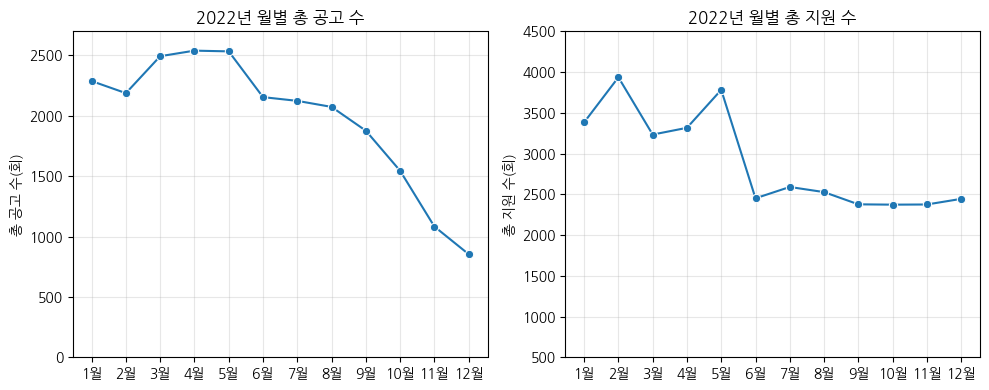

In [ ]:
# 2022년 월별 총 공고 수, 총 지원 수
all_2022_app = job_df[job_df['start_date'].dt.year == 2022].groupby(job_df['start_date'].dt.month).size()
sm_2022_app = job_df[job_df['start_date'].dt.year == 2022].groupby(job_df['start_date'].dt.month).agg({'apply_count': 'sum'})

fig, ax = plt.subplots(figsize=(10, 4), ncols=2)

sns.lineplot(x=all_2022_app.index, y=all_2022_app.values, ax=ax[0], marker='o')
sns.lineplot(x=sm_2022_app.index, y=sm_2022_app.values.reshape(1, -1)[0], ax=ax[1], marker='o')

for a in ax:
    a.set_xticks(range(1, 13))
    a.set_xticklabels([f'{m}월' for m in range(1, 13)])

ax[0].set_title('2022년 월별 총 공고 수')
ax[0].set_xlabel('')
ax[0].set_ylabel('총 공고 수(회)')
ax[0].set_ylim([0, 2700])
ax[0].grid(alpha=0.3)

ax[1].set_title('2022년 월별 총 지원 수')
ax[1].set_xlabel('')
ax[1].set_ylabel('총 지원 수(회)')
ax[1].set_ylim([500, 4500])
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

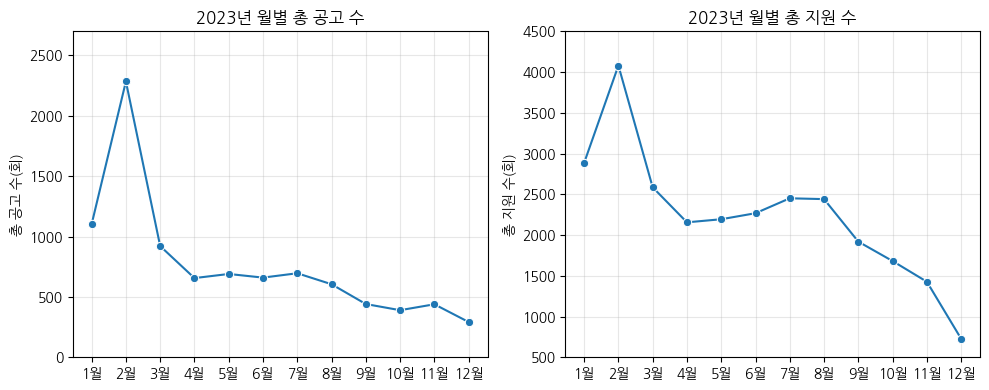

In [ ]:
# 2023년 월별 총 공고 수, 총 지원 수
all_2023_app = job_df[job_df['start_date'].dt.year == 2023].groupby(job_df['start_date'].dt.month).size()
sm_2023_app = job_df[job_df['start_date'].dt.year == 2023].groupby(job_df['start_date'].dt.month).agg({'apply_count': 'sum'})

fig, ax = plt.subplots(figsize=(10, 4), ncols=2)

sns.lineplot(x=all_2023_app.index, y=all_2023_app.values, ax=ax[0], marker='o')
sns.lineplot(x=sm_2023_app.index, y=sm_2023_app.values.reshape(1, -1)[0], ax=ax[1], marker='o')

for a in ax:
    a.set_xticks(range(1, 13))
    a.set_xticklabels([f'{m}월' for m in range(1, 13)])

ax[0].set_title('2023년 월별 총 공고 수')
ax[0].set_xlabel('')
ax[0].set_ylabel('총 공고 수(회)')
ax[0].set_ylim([0, 2700])
ax[0].grid(alpha=0.3)

ax[1].set_title('2023년 월별 총 지원 수')
ax[1].set_xlabel('')
ax[1].set_ylabel('총 지원 수(회)')
ax[1].set_ylim([500, 4500])
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# csv 파일 만들기
# all_2022_app.to_csv('2022년 총 공고수.csv')
# all_2023_app.to_csv('2023년 총 공고수.csv')
# sm_2022_app.to_csv('2022년 총 지원수.csv')
# sm_2023_app.to_csv('2023년 총 지원수.csv')

### 월별 지원을 많이 받은 상위 20개 공고의 평균 지원 수

In [ ]:
# 2022년
job_2022 = job_df[job_df['start_date'].dt.year == 2022]
top_2022 = []
top_mean_2022 = []

for month in range(1, 13):
    top_2022.append(job_2022[job_2022['start_date'].dt.month == month].sort_values(by='apply_count', ascending=False).head(20)['apply_count'])
    top_mean_2022.append(job_2022[job_2022['start_date'].dt.month == month].sort_values(by='apply_count', ascending=False).head(20)['apply_count'].mean())

top_mean_2022 = np.round(top_mean_2022, 1)

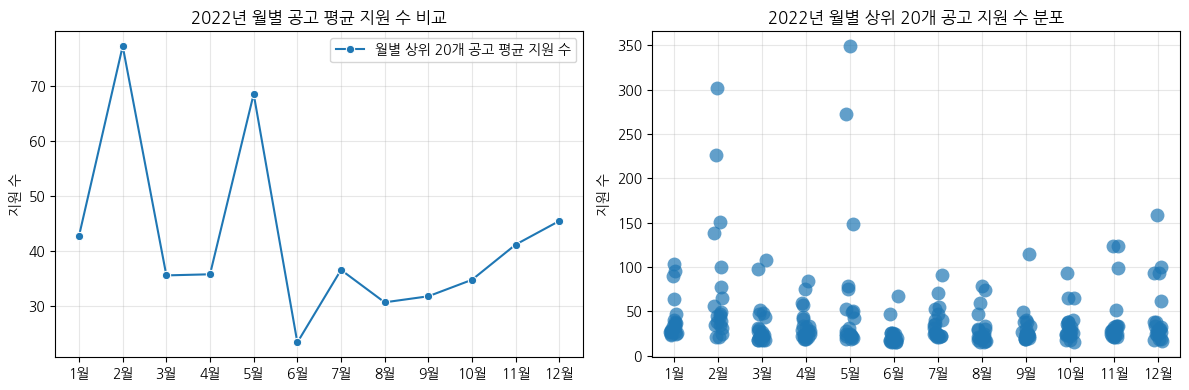

In [ ]:
# 2022년 시각화
months = range(1, 13)
top_mean_2022 = pd.Series(top_mean_2022, index=[f'{m}월' for m in months])

plot_2022_df = pd.concat(
    [pd.Series(values).to_frame('지원수').assign(월=month)
     for month, values in enumerate(top_2022, start=1)],
    ignore_index=True
)
plot_2022_df['월'] = plot_2022_df['월'].astype(str) + '월'

fig, ax = plt.subplots(figsize=(12, 4), ncols=2)

sns.lineplot(x=top_mean_2022.index, y=top_mean_2022.values, marker='o', label='월별 상위 20개 공고 평균 지원 수', ax=ax[0])
sns.stripplot(x='월', y='지원수', data=plot_2022_df, jitter=True, size=10, alpha=0.7, ax=ax[1])

for a in ax:
    a.set_xlabel('')
    a.set_ylabel('지원 수')
    a.grid(alpha=0.3)

ax[0].set_title('2022년 월별 공고 평균 지원 수 비교')
ax[1].set_title('2022년 월별 상위 20개 공고 지원 수 분포')

plt.tight_layout()
plt.show()

In [ ]:
# 2023년
job_2023 = job_df[job_df['start_date'].dt.year == 2023]
top_2023 = []
top_mean_2023 = []

for month in range(1, 13):
    top_2023.append(job_2023[job_2023['start_date'].dt.month == month].sort_values(by='apply_count', ascending=False).head(20)['apply_count'])
    top_mean_2023.append(job_2023[job_2023['start_date'].dt.month == month].sort_values(by='apply_count', ascending=False).head(20)['apply_count'].mean())

top_mean_2023 = np.round(top_mean_2023, 1)

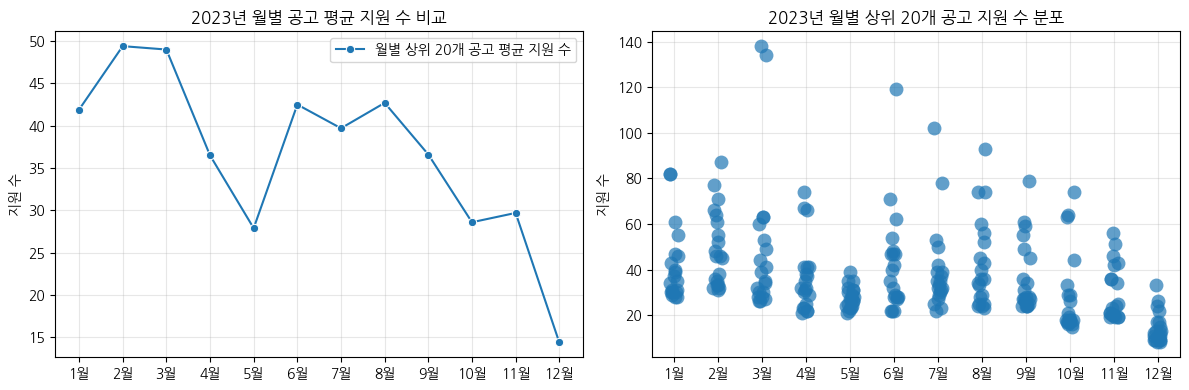

In [ ]:
# 2023년 시각화
months = range(1, 13)
top_mean_2023 = pd.Series(top_mean_2023, index=[f'{m}월' for m in months])

plot_2023_df = pd.concat(
    [pd.Series(values).to_frame('지원수').assign(월=month)
     for month, values in enumerate(top_2023, start=1)],
    ignore_index=True
)
plot_2023_df['월'] = plot_2023_df['월'].astype(str) + '월'

fig, ax = plt.subplots(figsize=(12, 4), ncols=2)

sns.lineplot(x=top_mean_2023.index, y=top_mean_2023.values, marker='o', label='월별 상위 20개 공고 평균 지원 수', ax=ax[0])
sns.stripplot(x='월', y='지원수', data=plot_2023_df, jitter=True, size=10, alpha=0.7, ax=ax[1])

for a in ax:
    a.set_xlabel('')
    a.set_ylabel('지원 수')
    a.grid(alpha=0.3)

ax[0].set_title('2023년 월별 공고 평균 지원 수 비교')
ax[1].set_title('2023년 월별 상위 20개 공고 지원 수 분포')

plt.tight_layout()
plt.show()

In [ ]:
# csv 파일 만들기
# top_mean_2022.to_csv('2022년 월별 상위 20개 공고의 평균 지원 수.csv')
# plot_2022_df.to_csv('2022년 월별 상위 20개 공고의 개별 지원 수.csv')
# top_mean_2023.to_csv('2023년 월별 상위 20개 공고의 평균 지원 수.csv')
# plot_2023_df.to_csv('2023년 월별 상위 20개 공고의 개별 지원 수.csv')

### 월별 지원을 많이 받은 상위 20개 공고의 특징 (모집분야, 모집경력, 근무위치, 급여공개여부, 원격근무가능여부)

In [ ]:
job_2022['month'] = job_2022['start_date'].dt.month
job_2023['month'] = job_2023['start_date'].dt.month

top20_2022_by_month = job_2022.sort_values(['month', 'apply_count'], ascending=[True, False]).groupby('month').head(20).reset_index(drop=True)
top20_2023_by_month = job_2023.sort_values(['month', 'apply_count'], ascending=[True, False]).groupby('month').head(20).reset_index(drop=True)

In [ ]:
top20_2022_by_month

,cdate,mdate,job_field,career_type_string,start_date,end_date,allow_remote,can_show_salary,job_uuid,company_uuid,apply_count,month
0,2022-01-07 03:17:14,2022-09-30 00:23:42,SW 개발,"신입,경력",2022-01-07,2022-12-30,0,1,ddde99dd-4db5-47eb-b052-482bece1cc47,66187dc5-7204-4084-ab96-e656c72e3730,104,1
1,2021-04-08 09:22:23,2022-11-18 09:22:31,SW 개발,"신입,경력",2022-01-01,2022-11-18,0,0,a8ddf2b5-148f-48c2-89da-eb5d54d476e9,dc733680-0cfb-4a57-8b64-2535c8c7c268,96,1
2,2020-09-30 05:15:34,2024-04-30 06:34:26,SW 개발,경력,2022-01-01,2024-05-31,0,0,a7bdb44b-8b8b-410f-8c37-ab67ad01dc6c,dc733680-0cfb-4a57-8b64-2535c8c7c268,90,1
3,2022-01-10 02:10:56,2023-01-11 10:11:07,SW 개발,"신입,경력",2022-01-10,2023-01-11,0,1,b42f56f1-a35b-4c01-97be-d2b324e56c1e,783e2f91-7c79-4b48-bad5-16a8240ffbc7,64,1
4,2022-01-24 10:22:40,2022-06-24 08:33:59,SW 개발,"신입,인턴",2022-01-24,2022-06-24,0,0,4aaed960-2361-46f5-b464-34e7689e93ae,7dd9d93d-efe0-4340-8b2f-e3de3a1a5333,47,1
...,...,...,...,...,...,...,...,...,...,...,...,...
235,2022-12-08 09:29:20,2023-02-06 01:34:52,SW 개발,신입,2022-12-08,2023-02-06,0,1,8e7eb72f-0722-4ac5-a5bc-7cd84725d8fb,494fca71-d955-42de-bae4-4ac9a232d06d,23,12
236,2022-12-13 06:15:54,2022-12-13 06:15:54,SW 개발,"신입,경력",2022-12-13,2022-12-26,0,0,cf123f94-802c-49be-88d4-ce2b98229c25,a4c1aba7-53e7-4ffc-920a-5bcbc6e36cc9,19,12
237,2022-12-27 09:13:17,2023-11-14 01:51:45,SW 개발,경력,2022-12-27,2023-11-14,1,0,fed2c003-9f7a-4c3c-9bff-296e8a4e952d,aec7ddf8-45fb-46fb-b964-47f2697cbbb9,19,12
238,2022-12-17 09:00:50,2022-12-17 09:00:50,SW 개발,"신입,인턴",2022-12-17,2023-01-01,0,1,f8efc69f-37d2-4de2-a77b-1899d7945b5c,6c5a1bdd-f438-4695-afc8-c3d919ae06da,18,12


#### 모집 분야

- 지원하는 공고의 다양성 부족 -> SW 개발에 지원하는 사용자가 다수 -> 다른 모집분야에 지원하고 싶은 유저들은 계속 이탈할지도 모름
- 다른 관점으로는 SW 개발 분야의 채용 공고를 더욱 많이 끌고와서 개발자 특화 플랫폼으로 전환

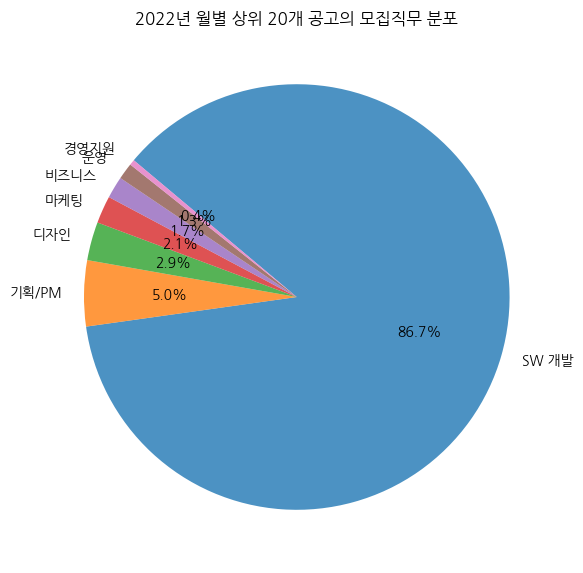

In [ ]:
# 2022년
counts_2022 = top20_2022_by_month['job_field'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    counts_2022,
    labels=counts_2022.index,
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False,
    wedgeprops={'alpha': 0.8}
)

plt.title('2022년 월별 상위 20개 공고의 모집직무 분포')
plt.tight_layout()
plt.show()

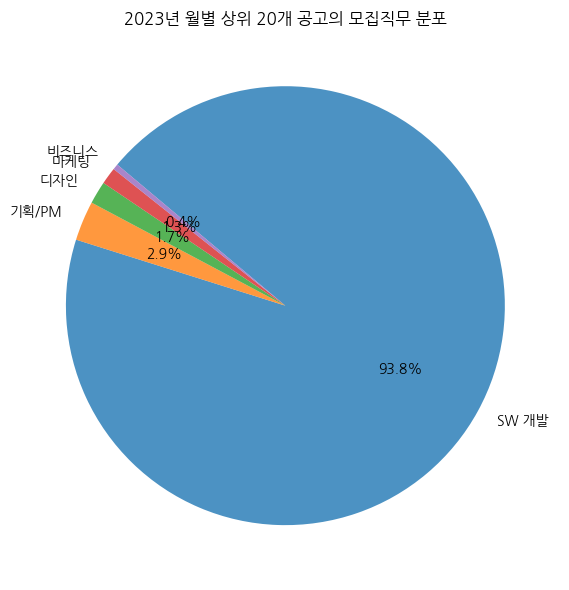

In [ ]:
# 2023년
counts_2023 = top20_2023_by_month['job_field'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    counts_2023,
    labels=counts_2023.index,
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False,
    wedgeprops={'alpha': 0.8}
)

plt.title('2023년 월별 상위 20개 공고의 모집직무 분포')
plt.tight_layout()
plt.show()

#### 모집경력

- 경력직에 지원하는 경우가 많음

In [ ]:
career_type = ['신입', '인턴', '경력']

In [ ]:
# 2022년
career_2022_count = dict()

for career in career_type:
    career_2022_count[career] = sum(top20_2022_by_month['career_type_string'].str.contains(career))

career_2022_df = pd.DataFrame.from_dict(career_2022_count, orient='index', columns=['지원 수'])

In [ ]:
top20_2022_by_month['career_type_string'].value_counts()

career_type_string
신입,경력       104
경력           79
신입,경력,인턴     28
신입           13
신입,인턴         9
인턴            7
Name: count, dtype: int64

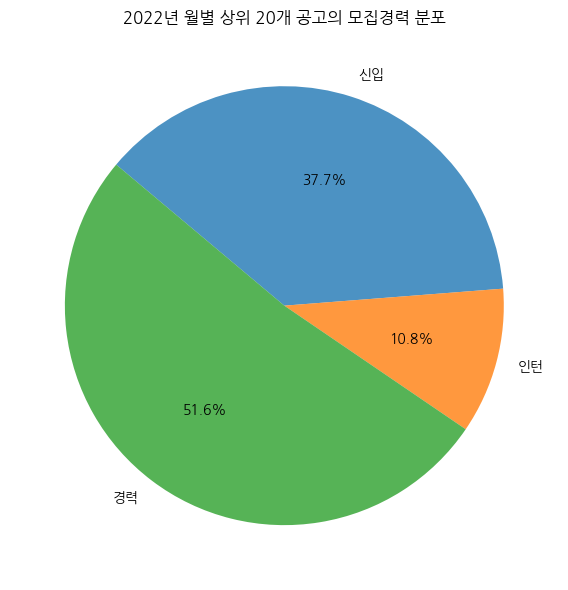

In [ ]:
# 시각화
plt.figure(figsize=(6, 6))
plt.pie(
    career_2022_df.values.reshape(-1),
    labels=career_2022_df.index,
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False,
    wedgeprops={'alpha': 0.8}
)

plt.title('2022년 월별 상위 20개 공고의 모집경력 분포')
plt.tight_layout()
plt.show()

In [ ]:
# 2023년
career_2023_count = dict()

for career in career_type:
    career_2023_count[career] = sum(top20_2023_by_month['career_type_string'].str.contains(career))

career_2023_df = pd.DataFrame.from_dict(career_2023_count, orient='index', columns=['지원 수'])

In [ ]:
top20_2023_by_month['career_type_string'].value_counts()

career_type_string
신입,경력       99
경력          98
신입,경력,인턴    26
신입           8
인턴           5
신입,인턴        4
Name: count, dtype: int64

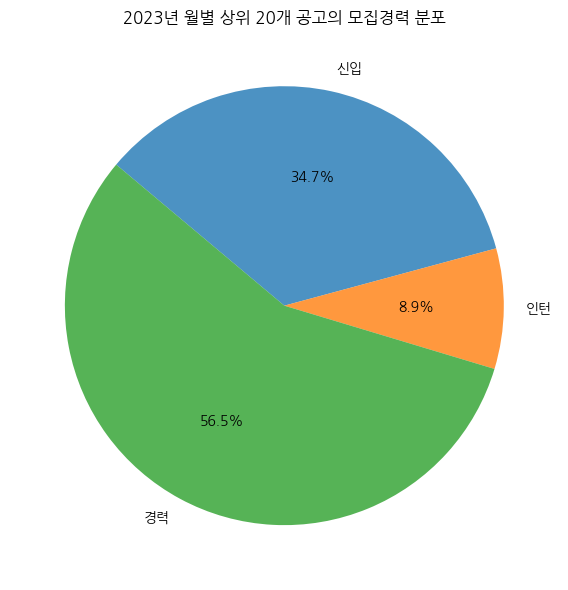

In [ ]:
# 시각화
plt.figure(figsize=(6, 6))
plt.pie(
    career_2023_df.values.reshape(-1),
    labels=career_2023_df.index,
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False,
    wedgeprops={'alpha': 0.8}
)

plt.title('2023년 월별 상위 20개 공고의 모집경력 분포')
plt.tight_layout()
plt.show()

#### 근무위치

- 채용 공고에 나와있는 위치가 job_add에 없으면 cp_add에서 확인 cp_add에도 없으면 결측값으로
- 성남시, 대전광역시말고는 모두 서울에 밀집

In [ ]:
# 데이터프레임 병합
# job과 병합하면 모두 결측 -> company로 병합
job_add = pd.concat([job_add_seoul_df, job_add_non_seoul_df], axis=0)[['job_uuid', 'address']]
cp_add = pd.concat([cp_add_seoul_df, cp_add_non_seoul_df], axis=0)[['company_uuid', 'address']]

In [ ]:
top20_2022_add = top20_2022_by_month.merge(cp_add, on='company_uuid', how='left')['address'].value_counts().head(10)
top20_2023_add = top20_2023_by_month.merge(cp_add, on='company_uuid', how='left')['address'].value_counts().head(10)

In [ ]:
top20_2022_add

address
강남구          112
서초구           33
마포구           24
관악구           18
경기도 성남시       18
성동구           15
중구            13
영등포구           9
대전광역시 유성구      8
구로구            8
Name: count, dtype: int64

In [ ]:
top20_2023_add

address
강남구          104
서초구           26
마포구           23
경기도 성남시       22
대전광역시 유성구     13
성동구           13
중구            10
영등포구           9
종로구            8
송파구            7
Name: count, dtype: int64

#### 원격근무 가능 여부

In [ ]:
allow_remote_2022 = top20_2022_by_month['allow_remote'].value_counts()
allow_remote_2022

allow_remote
0    174
1     66
Name: count, dtype: int64

In [ ]:
allow_remote_2023 = top20_2023_by_month['allow_remote'].value_counts()
allow_remote_2023

allow_remote
0    199
1     41
Name: count, dtype: int64

#### 급여 공개 여부

In [ ]:
can_show_salary_2022 = top20_2022_by_month['can_show_salary'].value_counts()
can_show_salary_2022

can_show_salary
0    140
1    100
Name: count, dtype: int64

In [ ]:
can_show_salary_2023 = top20_2023_by_month['can_show_salary'].value_counts()
can_show_salary_2023

can_show_salary
0    156
1     84
Name: count, dtype: int64

In [ ]:
# csv 파일 만들기
# counts_2022.to_csv('2022년 모집직무 분포.csv')
# counts_2023.to_csv('2023년 모집직무 분포.csv')

# career_2022_df.to_csv('2022년 모집경력 분포.csv')
# career_2023_df.to_csv('2023년 모집경력 분포.csv')

# top20_2022_add.to_csv('2022년 근무지 분포.csv')
# top20_2023_add.to_csv('2023년 근무지 분포.csv')

# allow_remote_2022.to_csv('2022년 원격근무 가능여부.csv')
# allow_remote_2023.to_csv('2023년 원격근무 가능여부.csv')

# can_show_salary_2022.to_csv('2022년 급여 공개 여부.csv')
# can_show_salary_2023.to_csv('2023년 급여 공개 여부.csv')

## 로그 데이터를 통한 유저 행동 정의

### UTM 데이터 해석표

| utm\_campaign                            | utm\_source            | utm\_medium   | utm\_content                | 해석                                      |
| ---------------------------------------- | ---------------------- | ------------- | --------------------------- | --------------------------------------- |
| friend\_request                          | facebook               | post          |                             | 페이스북 포스트(게시글)에서 유입됨                     |
| google\_jobs\_apply                      | instagram              | click         | 210208\_IG\_lo              | 인스타그램 클릭, 콘텐츠 ID 210208\_IG\_lo 유입      |
|                                    | kakaochatbot           | organic       | find\_account               | 카카오 챗봇 > 검색 > 계정 찾기 기능에서 유입             |
| 5b30e868bc-                              | google\_jobs\_apply    | organic       |                             | 구글 검색을 통한 유입                            |
|                                     | email                  |          |                             | 출처는 없지만 이메일을 통해 유입됨                     |
| facebook\_recommendation\_dataanalystrp  | notification           | email         | user\_261270\_profile       | 알림 > 이메일 > user\_261270\_profile 페이지 유입 |
| 210208\_IG\_lo\_02                       | Rocketpunch Recruit    | email         |                             | Rocketpunch 리크루팅 이메일 클릭 유입              |
| wnc\_594600                              | RocketPunch Newsletter | email         |                             | RocketPunch 뉴스레터 이메일 유입                 |
| cs                                       | email                  | email         | email-20220311-RP           | 이메일 마케팅 캠페인 (날짜 포함) 유입                  |
| 4597a04bf2-EMAIL\_CAMPAIGN\_2018\_05\_16 | linkedin               | social        | 208574257                   | 링크드인 통해 유입, 콘텐츠 ID 포함                   |
| companypage                              | linktree\_n            | social        | 220128\_taste\_all\_recruit | 링크트리 소셜 미디어 통해 캠페인 페이지 유입               |
|                                      | facebook               | social        |                             | 페이스북 소셜 미디어 클릭 유입                       |
| google\_jobs\_apply                      | brunch                 | social        |                             | 브런치 플랫폼 소셜 유입                           |
| taste\_all                               | job\_widget            | widget        | user\_profile               | 외부 채용 위젯 클릭 → user\_profile로 유입         |
| SOPT                                     | widget                 | advertisement | job                         | 광고용 위젯 → 채용 공고 페이지 유입                   |
| job\_widget                              | iweb                   | marketing     |                             | iweb 마케팅 채널 유입                          |
|                                       | 45s                    |          |                         | 광고 소스 45s, 제휴 코드 가능성                    |
|                                    | medium                 |            |                       | medium(블로그?) 출처, 상세 정보 없음               |
|                                      | notification           |            |                        | 알림 기능에서 유입, 방식/콘텐츠 정보 없음                |
| job\_ad                                  | pocket\_mylist         |          |                         | 북마크 또는 즐겨찾기 유사 기능 통해 유입 (추정)            |
| uxuidesigner\_f                          | gnb                    |           |                         | 상단 메뉴(GNB) 클릭 유입, 내부 링크일 가능성            |
|                                      | pocket\_saves          |           |                       | 저장한 포지션 기능에서 유입 (내부 기능일 가능성)            |
| advertisement                            | brunch                 |        |               | 브런치 블로그 플랫폼의 소셜 유입                      |
| companies\_tumblbug\_jobs                | wnc\_594600            | gamma         | msg\_638303                 | 제휴사 wnc 통해 gamma 캠페인 유입, 메시지 ID 포함      |

### 유저 행동 정의

https://docs.google.com/spreadsheets/d/1-5654hcZEIEftn4NUvkU6-N_IzLmmXok/edit?gid=784064778#gid=784064778

# 6. AARRR 프레임워크
- 회원 가입 과정을 총 3 단계의 필수 step 정의
    - step1/name(인적사항)
    - step2/career(경력사항)
    - step3/done까지 찍힌 경우 회원가입을 완료한 경우로 정의
    - 나머지 경우들은 선택사항으로 간주

- 채용 공고에 지원 과정을 총 4 단계의 필수 step 정의
    - step1(특정 채용 공고 지원 1단계 지원자 주요 정보 기입)
    - step2(특정 채용 공고 지원 2단계 공모전수상, 자격증 등등 기입)
    - step3(특정 채용 공고 지원 3단계 -> 포트폴리오 제출)
    - step4(사실확인동의)
    - 'api/jobs/id/apply/step4' 로그가 찍힌 유저는 채용 공고에 지원 완료한 경우로 정의

- 같은 날짜에 여러번 방문하는 경우, 마지막 로그 이후 1시간이 지나면 해당 세션 종료되고 그 이후의 방문은 새로운 세션으로 간주

## Acquisition(획득)

In [ ]:
# 22년, 23년 로그데이터 병합
log_clean = pd.concat([log_2022_clean, log_2023_clean], axis=0)

### 신규 가입자
- sum(signup_done['user_uuid'].duplicated()) -> 472건 (가입날짜 같은 경우, 다른 경우 모두 포함)
- signup_done.groupby(['user_uuid', 'date']).size().reset_index()[signup_done.groupby(['user_uuid', 'date']).size().reset_index()['user_uuid'].duplicated()] -> 가입날짜가 다른 경우 210건
- 동일한 유저가 다른 가입 날짜에 여러번 회원 가입한 경우 중 그 경우가 3회 이상인 유저는 제외 (이상 유저로 판단하여 제거하는게 분석에 용이하다고 판단)
- 2회 이하인 경우는 가장 먼저 찍힌 기록을 회원가입 시점으로 정의
- 그 이후로 나오는 signup을 포함한 기록은 오류로 간주 -> 삭제
- 최종 신규 가입자: 4,686명

In [ ]:
signup_done_v1 = log_clean[log_clean['URL'] == 'signup/step3/done']

In [ ]:
# 다른 가입 날짜에 여러번 회원 가입한 경우가 3회 이상인 유저 (14명)

# signup_done_v1.groupby(['user_uuid', 'date']).size().reset_index() -> 유저,날짜별 묶음
# signup_done_v1.groupby(['user_uuid', 'date']).size().reset_index()[signup_done_v1.groupby(['user_uuid', 'date']).size().reset_index()['user_uuid'].duplicated(keep=False)] -> 서로 다른 날짜에 회원 가입한 경우(유저 기준 중복 확인)
signup_3_over = signup_done_v1.groupby(['user_uuid', 'date']).size().reset_index()[signup_done_v1.groupby(['user_uuid', 'date']).size().reset_index()['user_uuid'].duplicated(keep=False)]['user_uuid'].value_counts().head(14).index

In [ ]:
log_clean_v1 = log_clean[~log_clean['user_uuid'].isin(signup_3_over)]

In [ ]:
# 회원가입 완료 인원 5172명 -> 5066명
signup_done_v2 = log_clean_v1[log_clean_v1['URL'] == 'signup/step3/done']

In [ ]:
# 가장 먼저 찍힌 기록을 회원가입 시점으로 정의
# 그 이후로 나오는 signup 포함 기록은 오류로 간주 -> 삭제
signup_done_v3 = signup_done_v2[~signup_done_v2['user_uuid'].duplicated(keep='first')]

In [ ]:
# 유저별 가입일 맵 생성
signup_date_map = signup_done_v3.set_index('user_uuid')['timestamp']

# log_signup_del에 signup_timestamp 매핑
log_signup_del = log_clean_v1.copy()
log_signup_del['signup_timestamp'] = log_signup_del['user_uuid'].map(signup_date_map)

# 삭제할 행 마스크 정의
mask = (log_signup_del['URL'].str.contains('signup') & (log_signup_del['timestamp'] > log_signup_del['signup_timestamp']))

# 해당 행 삭제
log_clean_v2 = log_signup_del.loc[~mask].drop(columns='signup_timestamp')

In [ ]:
# 최종 회원가입 완료 인원 5066명 -> 4686명
signup_done_v4 = log_clean_v2[log_clean_v2['URL'] == 'signup/step3/done']

In [ ]:
signup_done_v4['year_month'] = signup_done_v4['date'].dt.strftime('%Y년 %m월')

In [ ]:
monthly_signup = pd.DataFrame(signup_done_v4.groupby('year_month').size(), columns=['count'])

In [ ]:
# monthly_signup.to_csv('월별 신규 가입자.csv')

### 월별 방문자 수
- 월별 방문자 수 추이
- 단순 플랫폼 방문 수 카운트
- 점차 감소하는 추세 사용자들이 빠져나가고 있음

In [ ]:
# 유저·날짜에 따라 사용자 월별 총 방문 수 계산
daily_visit = log_clean_v2[['user_uuid', 'date']].drop_duplicates(keep='first')
daily_visit['year_month'] = daily_visit['date'].dt.strftime('%Y년 %m월')

monthly_visit = pd.DataFrame(daily_visit.groupby('year_month').size(), columns=['count'])
monthly_people = pd.DataFrame(daily_visit[['user_uuid', 'year_month']].drop_duplicates(keep='first').groupby('year_month').size(), columns=['count'])

In [ ]:
monthly_visit

,count
year_month,
2022년 01월,30622
2022년 02월,26390
2022년 03월,29197
2022년 04월,27282
2022년 05월,28707
2022년 06월,26489
2022년 07월,25536
2022년 08월,25680
2022년 09월,22106


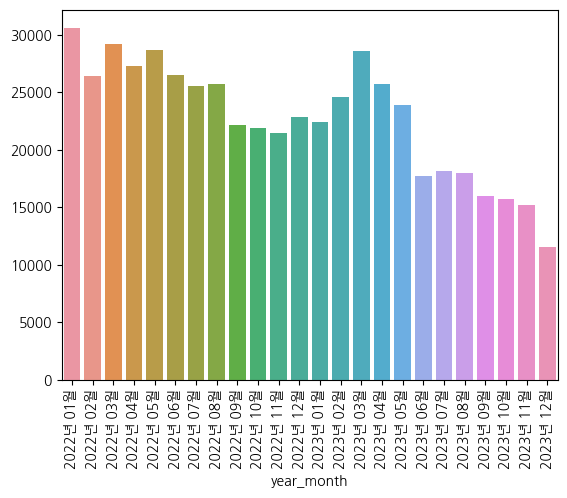

In [ ]:
# 22년, 23년 월별 총 방문 수 추이
sns.barplot(x=monthly_visit.index, y=monthly_visit.values.reshape(1, -1)[0])

plt.xticks(rotation=90)
plt.show()

In [ ]:
monthly_people

,count
year_month,
2022년 01월,7070
2022년 02월,6464
2022년 03월,6637
2022년 04월,6353
2022년 05월,6540
2022년 06월,6304
2022년 07월,6284
2022년 08월,6246
2022년 09월,5672


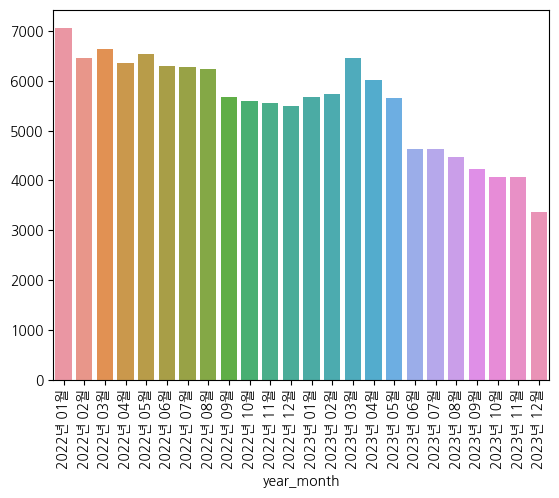

In [ ]:
# 2022년 월별 방문하는 사용자 수 추이
sns.barplot(x=monthly_people.index, y=monthly_people.values.reshape(1, -1)[0])

plt.xticks(rotation=90)
plt.show()

In [ ]:
# 월별 사용자들의 평균 방문 수
monthly_mean_people = np.round((monthly_visit['count'] / monthly_people['count']), 2)
monthly_mean_people

year_month
2022년 01월    4.33
2022년 02월    4.08
2022년 03월    4.40
2022년 04월    4.29
2022년 05월    4.39
2022년 06월    4.20
2022년 07월    4.06
2022년 08월    4.11
2022년 09월    3.90
2022년 10월    3.90
2022년 11월    3.87
2022년 12월    4.16
2023년 01월    3.95
2023년 02월    4.29
2023년 03월    4.42
2023년 04월    4.27
2023년 05월    4.23
2023년 06월    3.84
2023년 07월    3.92
2023년 08월    4.03
2023년 09월    3.79
2023년 10월    3.87
2023년 11월    3.72
2023년 12월    3.44
Name: count, dtype: float64

In [ ]:
# csv 파일로 내보내기
# monthly_visit.to_csv('월별 총 방문 수 추이.csv')
# monthly_people.to_csv('월별 총 방문자 수 추이.csv')
# monthly_mean_people.to_csv('월별 평균 방문 수 추이.csv')

## Activation(활성화)

### 채용공고 페이지 뷰(PV, Page View)
- 로그에 'api/jobs'가 찍힌 경우는 채용 페이지 관련 접근으로 간주
- 'jobs/id/id_title'를 포함하는 경우는 채용 공고 상세 페이지 접근으로 간주

In [ ]:
# 채용공고 확인
page_view = log_clean_v2[log_clean_v2['URL'].str.contains('jobs/id/id_title')]
page_view['year_month'] = page_view['date'].dt.strftime('%Y년 %m월')

In [ ]:
page_view_count = page_view.groupby('year_month').size()
page_view_people = page_view[['user_uuid','year_month']].drop_duplicates(keep='first').groupby('year_month').size()

In [ ]:
page_view_count

year_month
2022년 01월    73074
2022년 02월    65365
2022년 03월    74067
2022년 04월    66009
2022년 05월    63375
2022년 06월    58601
2022년 07월    52436
2022년 08월    55788
2022년 09월    48209
2022년 10월    47754
2022년 11월    45755
2022년 12월    51227
2023년 01월    45677
2023년 02월    57940
2023년 03월    59897
2023년 04월    56948
2023년 05월    54156
2023년 06월    38567
2023년 07월    33574
2023년 08월    36527
2023년 09월    29379
2023년 10월    28025
2023년 11월    25497
2023년 12월    13985
dtype: int64

In [ ]:
page_view_people

year_month
2022년 01월    3972
2022년 02월    3570
2022년 03월    3730
2022년 04월    3417
2022년 05월    3542
2022년 06월    3275
2022년 07월    3292
2022년 08월    3256
2022년 09월    2921
2022년 10월    2850
2022년 11월    2804
2022년 12월    2908
2023년 01월    3010
2023년 02월    3068
2023년 03월    3264
2023년 04월    3034
2023년 05월    2804
2023년 06월    2272
2023년 07월    2193
2023년 08월    2139
2023년 09월    1946
2023년 10월    2021
2023년 11월    1984
2023년 12월    1469
dtype: int64

In [ ]:
page_view_count.values / page_view_people.values

array([18.39728097, 18.30952381, 19.85710456, 19.31782265, 17.89243365,
       17.89343511, 15.92831106, 17.13390663, 16.50427936, 16.75578947,
       16.31776034, 17.61588721, 15.17508306, 18.88526728, 18.35079657,
       18.76994067, 19.31383738, 16.97491197, 15.30962152, 17.07667134,
       15.0971223 , 13.86689758, 12.85131048,  9.52008169])

In [ ]:
# csv 파일로 내보내기
# page_view_count.to_csv('월별 채용공고 방문 추이.csv')
# page_view_people.to_csv('월별 채용공고 방문자 추이.csv')

### 평균 세션 시간(Average Session Duration)
- 마지막 로그에서 얼마나 머물렀는지 알 수 없다는 한계 존재
- 세션 시간이 최소 1분 이상이 되어야 조금이나마 탐색을 해봤다고 정의

In [ ]:
# 로그
log_session = log_clean_v2.copy()

# 이전 timestamp 계산
log_session['prev_ts'] = log_session.groupby('user_uuid')['timestamp'].shift(1)

# 시간 차이(시간 단위) 계산
log_session['diff_seconds'] = (log_session['timestamp'] - log_session['prev_ts']).dt.total_seconds()
log_session['diff_hours'] = (log_session['timestamp'] - log_session['prev_ts']).dt.total_seconds() / 3600

# 새로운 세션 여부 판단
log_session['new_session'] = (log_session['diff_hours'] > 1) | (log_session['prev_ts'].isna())

# 세션 번호 누적합
log_session['session_num'] = log_session.groupby('user_uuid')['new_session'].cumsum().astype(int)

In [ ]:
# 세션 계산 후 예시
log_session.head()

,user_uuid,URL,timestamp,date,response_code,method,prev_ts,diff_seconds,diff_hours,new_session,session_num
449898,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-01-15 07:44:06,2022-01-15,200,GET,NaT,NaN,NaN,True,1
449899,0002535c-eacb-456b-a620-92c917332ba3,api/users/id/template,2022-01-15 07:44:08,2022-01-15,200,POST,2022-01-15 07:44:06,2.0,0.000556,False,1
449945,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-03-01 05:45:33,2022-03-01,200,GET,2022-01-15 07:44:08,3880885.0,1078.023611,True,2
449931,0002535c-eacb-456b-a620-92c917332ba3,api/users/id/template,2022-03-01 05:45:35,2022-03-01,200,POST,2022-03-01 05:45:33,2.0,0.000556,False,2
449907,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-04-18 15:12:10,2022-04-19,200,GET,2022-03-01 05:45:35,4181195.0,1161.443056,True,3


In [ ]:
# 세션별 시작 월
session_date = log_session[['user_uuid', 'session_num', 'timestamp']]
session_date['year_month'] = session_date['timestamp'].dt.strftime('%Y년 %m월')
session_date = session_date[~session_date[['user_uuid', 'session_num']].duplicated(keep='first')]

In [ ]:
# 세션별 시간 계산(초 단위)
session_time = log_session[log_session['new_session'] == False].groupby(['user_uuid', 'date','session_num']).agg({'diff_seconds': 'sum'}).reset_index()

In [ ]:
# 2분 이상 접속한 세션만 선택
session_over_120 = session_time[session_time['diff_seconds'] >= 120]

In [ ]:
# 세션 체류 시간과 시작 월 합치기
session_time_month = pd.merge(session_over_120, session_date, how='left', on=['user_uuid', 'session_num'])

In [ ]:
# 월별 세션 평균 체류 시간 계산
mean_session_time = session_time_month.groupby('year_month').agg({'diff_seconds': 'mean'})
mean_session_time = pd.DataFrame(mean_session_time.values, index=mean_session_time.index, columns=['mean_seconds'])

In [ ]:
mean_session_time['mins'] = (mean_session_time['mean_seconds'] // 60).astype(int)
mean_session_time['secs'] = (mean_session_time['mean_seconds'] % 60).round().astype(int)

# 예: "29m 47s" 처럼 문자열로 합치기
mean_session_time['mean_time_str'] = mean_session_time['mins'].astype(str) + 'm ' + mean_session_time['secs'].astype(str) + 's'
mean_session_time['mean_minutes_dec'] = mean_session_time['mins'] + mean_session_time['secs'] / 100.0

In [ ]:
mean_session_time

,mean_seconds,mins,secs,mean_time_str,mean_minutes_dec
year_month,,,,,
2021년 12월,1768.053571,29,28,29m 28s,29.28
2022년 01월,1824.692488,30,25,30m 25s,30.25
2022년 02월,1816.093495,30,16,30m 16s,30.16
2022년 03월,1827.722038,30,28,30m 28s,30.28
2022년 04월,1912.964873,31,53,31m 53s,31.53
2022년 05월,1826.966881,30,27,30m 27s,30.27
2022년 06월,1790.526248,29,51,29m 51s,29.51
2022년 07월,1737.548936,28,58,28m 58s,28.58
2022년 08월,1722.682705,28,43,28m 43s,28.43


In [ ]:
np.mean(mean_session_time['mean_minutes_dec'])

28.481199999999998

In [ ]:
mean_session_time[mean_session_time['mean_minutes_dec'] == min(mean_session_time['mean_minutes_dec'])]

,mean_seconds,mins,secs,mean_time_str,mean_minutes_dec
year_month,,,,,
2023년 11월,1514.870619,25,15,25m 15s,25.15


In [ ]:
mean_session_time[mean_session_time['mean_minutes_dec'] == max(mean_session_time['mean_minutes_dec'])]

,mean_seconds,mins,secs,mean_time_str,mean_minutes_dec
year_month,,,,,
2022년 04월,1912.964873,31,53,31m 53s,31.53


### 회원가입 퍼널 분석
- 'signup/step1/name'(인적사항) -> 'signup/step2/career'(경력사항) -> 'signup/step3/done'(완료)
- 선택사항 'signup/step1/verify', 'signup/step2/education', 'signup/step3/discover', 'signup/step3/import' 로그들이 회원가입 퍼널에 영향을 미치는지도 확인
- 회원가입 정보를 저장해뒀다가 추후 다시 시도하는 경우가 있을 수 있음, 여기서는 정확하게 정해둔 순서대로 찍힌 퍼널 분석
- 회원가입이 가장 활발하게 이뤄진 기간 파악
- 각각의 단계까지 갔을 때 이탈한 이유 파악(completed한 경우와 비교하며 선택사항 등의 특징을 바탕으로)
- 회원가입 시도: 5,639건, 회원가입 완료: 3,568건

In [ ]:
signup_process = log_session[log_session['URL'].str.contains('signup/step')]

In [ ]:
# 퍼널 단계 정의(필수 사항)
required = ['signup/step1/name', 'signup/step2/career', 'signup/step3/done']

# 선택 사항 (step1→verify, step2→education, step3→discover, step3→import)
opt_verify    = 'signup/step1/verify'
opt_education = 'signup/step2/education'
opt_discover = 'signup/step3/discover'
opt_import = 'signup/step3/import'

In [ ]:
# 세션별 순회하며 각 유저/세션의 이탈 단계와 선택 단계 포함 여부 계산
records = []
for (user, sess), grp in signup_process.groupby(['user_uuid','session_num']):
    urls = grp['URL'].tolist()
    # 퍼널 시작점이 찍혔을 때만
    if required[0] in urls:
        # step1/name 최초 발생 시각
        first_ts = grp.loc[grp['URL']==required[0], 'timestamp'].min()
        
        # optional 단계 포함 여부
        has_verify    = opt_verify in urls
        has_education = opt_education in urls
        has_discover = opt_discover in urls
        has_import = opt_import in urls

        # 이탈 단계 찾기
        last_pos = urls.index(required[0])
        drop_at  = None
        for step in required[1:]:
            # 다음 필수 단계가 last_pos 이후에 있는지
            try:
                # enumerate로 위치 찾기
                pos = next(i for i,u in enumerate(urls[last_pos+1:], start=last_pos+1) if u==step)
                last_pos = pos
            except StopIteration:
                drop_at = step
                break

        # 모두 통과했으면 완료(completed) 처리
        if drop_at is None:
            drop_at = 'completed'

        records.append({
            'user_uuid': user,
            'first_ts': first_ts,
            'session_num': sess,
            'has_verify': has_verify,
            'has_education': has_education,
            'has_discover': has_discover,
            'has_import': has_import,
            'drop_off_at':  drop_at
        })

In [ ]:
# 결과 데이터 프레임
funnel_result = pd.DataFrame(records)
funnel_result

,user_uuid,first_ts,session_num,has_verify,has_education,has_discover,has_import,drop_off_at
0,000b55ad-5c86-438b-a5b0-9ea3a2917789,2023-06-21 11:01:34,1,False,False,True,True,completed
1,0017a738-4fcc-441e-983b-a6033890a9db,2022-04-08 11:52:14,1,False,True,True,True,completed
2,00605090-bd12-4978-884b-c74e093b40d0,2023-04-27 08:01:50,1,False,False,True,True,completed
3,006a406d-0e49-4e85-a171-e83ebcbb109a,2023-01-02 03:51:53,5,False,False,True,True,completed
4,00778343-487a-44c0-a1f2-895b993d148a,2023-07-24 01:26:53,1,False,True,True,True,completed
...,...,...,...,...,...,...,...,...
5634,ffde47f8-497e-4385-b708-31f22417b2cd,2022-09-15 00:50:00,1,False,False,True,True,completed
5635,ffe429f9-200e-472d-9d72-2742727c8ea8,2022-01-19 07:50:59,1,False,True,True,True,completed
5636,ffe6aee0-85cc-45e2-aa5e-129751dff08e,2022-11-18 03:14:45,1,False,True,True,True,completed
5637,ffee959d-51e1-41d1-b662-1e55c7c379bf,2023-01-05 11:10:38,1,False,True,True,True,completed


In [ ]:
# 이탈 지점 확인
# completed인 경우, 모든 step을 잘 밟고 회원가입 완료
# signup/step3/done인 경우, step2 단계까지는 완료하고 signup/step3 단계를 완료하지 못하고 이탈
# signup/step2/career인 경우, step1 단계까지는 완료하고 signup/step2 단계를 완료하지 못하고 이탈
funnel_result['drop_off_at'].value_counts()

drop_off_at
completed              3568
signup/step3/done      1042
signup/step2/career    1029
Name: count, dtype: int64

In [ ]:
# signup/step2에서 이탈 -> 1,029건
# signup/step1/verify 작성한 유저 -> 4건
funnel_result[funnel_result['drop_off_at'] == 'signup/step2/career']

,user_uuid,first_ts,session_num,has_verify,has_education,has_discover,has_import,drop_off_at
8,00855aeb-dea6-4edd-8bc1-4d94df97780e,2023-05-05 05:05:31,36,False,False,False,False,signup/step2/career
13,00dcb1ed-1cf3-4b84-8cb0-4c86b33123bd,2022-08-26 10:09:01,25,False,False,False,False,signup/step2/career
19,00f8df99-eaaf-4fd4-a15d-a6298d02aa45,2023-06-19 06:55:41,200,False,False,False,False,signup/step2/career
28,014d75ad-0a59-492a-84ec-1306ba822373,2023-11-01 01:26:31,192,False,False,False,False,signup/step2/career
35,018a6225-9652-4785-82e4-f746796da3cf,2022-05-30 06:48:24,1,False,False,False,False,signup/step2/career
...,...,...,...,...,...,...,...,...
5621,ff0d4e42-2118-4e5c-abf5-b8f1dc3c1c06,2023-09-21 10:26:32,28,False,False,False,False,signup/step2/career
5624,ff4ca40c-67bb-429f-8d5f-97198ad98bcd,2023-05-29 02:42:07,56,False,False,False,False,signup/step2/career
5628,ff773dc0-7163-48a0-8865-be8f56bc1754,2022-12-02 05:38:49,16,False,False,False,False,signup/step2/career
5631,ffac8b54-708c-46af-9e19-a3fbf587bf8a,2022-06-07 14:58:25,2,False,False,False,False,signup/step2/career


In [ ]:
# signup/step3에서 이탈 -> 1,042건
# signup/step1/verify 작성한 유저 -> 0건
# signup/step2/education 작성한 유저 -> 148건
funnel_result[funnel_result['drop_off_at'] == 'signup/step3/done']

,user_uuid,first_ts,session_num,has_verify,has_education,has_discover,has_import,drop_off_at
5,007f87f4-adf8-45be-a6be-8f7121f1cbaf,2022-02-07 02:56:51,1,False,False,False,False,signup/step3/done
7,008314c3-4837-40fc-be5a-b38d1072db30,2022-08-01 13:37:19,1,False,True,False,False,signup/step3/done
20,00fe56fe-5648-40ac-8d35-04bc61263c07,2022-05-19 08:24:17,1,False,True,False,False,signup/step3/done
21,00fe56fe-5648-40ac-8d35-04bc61263c07,2022-11-08 09:22:28,2,False,False,False,False,signup/step3/done
30,01567864-0b93-4e77-9491-5b81ede75ce6,2022-01-14 11:26:08,6,False,True,False,False,signup/step3/done
...,...,...,...,...,...,...,...,...
5615,feeb857e-cb30-43b4-95f2-0808311a9b40,2022-07-06 08:33:42,1,False,False,False,False,signup/step3/done
5616,feec0e97-78f3-4419-8a22-c77e9275983d,2023-07-05 07:11:54,1,False,False,False,False,signup/step3/done
5630,ffa9a6fd-73be-4c4d-ae0b-322635a2859d,2022-07-24 13:19:48,219,False,False,False,False,signup/step3/done
5633,ffd75368-f7ed-4eaf-9db9-0f76ef80af31,2022-05-20 09:41:54,26,False,False,False,False,signup/step3/done


In [ ]:
# 이탈하지 않고 회원가입 완료 -> 3,568건
# signup/step1/verify 작성한 유저 -> 0건
# signup/step2/education 작성한 유저 -> 1,140건
# signup/step3/discover 작성한 유저 -> 3,567건
# signup/step3/import 작성한 유저 -> 3,567건
funnel_result[funnel_result['drop_off_at'] == 'completed']

,user_uuid,first_ts,session_num,has_verify,has_education,has_discover,has_import,drop_off_at
0,000b55ad-5c86-438b-a5b0-9ea3a2917789,2023-06-21 11:01:34,1,False,False,True,True,completed
1,0017a738-4fcc-441e-983b-a6033890a9db,2022-04-08 11:52:14,1,False,True,True,True,completed
2,00605090-bd12-4978-884b-c74e093b40d0,2023-04-27 08:01:50,1,False,False,True,True,completed
3,006a406d-0e49-4e85-a171-e83ebcbb109a,2023-01-02 03:51:53,5,False,False,True,True,completed
4,00778343-487a-44c0-a1f2-895b993d148a,2023-07-24 01:26:53,1,False,True,True,True,completed
...,...,...,...,...,...,...,...,...
5629,ff7d3a25-3d55-4e64-bc6a-24827bb42068,2022-05-20 11:20:33,8,False,False,True,True,completed
5634,ffde47f8-497e-4385-b708-31f22417b2cd,2022-09-15 00:50:00,1,False,False,True,True,completed
5635,ffe429f9-200e-472d-9d72-2742727c8ea8,2022-01-19 07:50:59,1,False,True,True,True,completed
5636,ffe6aee0-85cc-45e2-aa5e-129751dff08e,2022-11-18 03:14:45,1,False,True,True,True,completed


### 채용공고 페이지 평균 체류 시간(Average Time on Page)
- 채용공고 페이지에서 바로 플랫폼에서 이탈한 경우는 제외(체류 시간을 계산하지 못함)
- 만약 다른 채용공고 페이지 진입 후 URL에 'api'가 포함되어 있으면 페이지 이동이 아니라 해당 페이지 내에서의 액션이라고 생각해서 페이지 이동이 아니라고 정의
- 실행 시간이 너무 오래걸려서 결과는 데이터프레임으로 다시 저장

```python
records = []

# 세션별 순회
for (user, sess), grp in log_session.groupby(['user_uuid','session_num']):
    # API 호출이 아닌 “페이지 네비게이션”만 추출
    page_nav = grp[~grp['URL'].str.contains('api', na=False)].sort_values('timestamp')
    
    # 채용 공고 페이지 진입으로 간주할 URL (jobs/id/id_title)
    job_entries = page_nav[page_nav['URL'].str.contains('jobs/id/id_title', na=False)]
    if job_entries.empty:
        continue
    
    # 2다음 페이지 이동 시점을 찾기 위해 merge_asof 사용
    job_entries = (job_entries[['timestamp']].rename(columns={'timestamp':'entry_ts'}).sort_values('entry_ts'))
    next_nav = pd.merge_asof(
        job_entries,
        page_nav[['timestamp']].rename(columns={'timestamp':'next_ts'}),
        left_on='entry_ts',
        right_on='next_ts',
        direction='forward',
        allow_exact_matches=False
    )
    
    # 체류 시간 계산 (초 단위)
    next_nav['dwell_s'] = (next_nav['next_ts'] - next_nav['entry_ts']).dt.total_seconds()
    # 마지막 네비게이션인 경우(next_ts가 NaT)는 제거
    next_nav = next_nav.dropna(subset=['dwell_s'])
    if next_nav.empty:
        continue
    
    # 기록 추가
    records.append({
        'user_uuid':       user,
        'session_num':     sess,
        'first_entry_ts':  job_entries['entry_ts'].min(),      # 세션 내 첫 진입 시각
        'avg_dwell_time':  next_nav['dwell_s'].mean()          # 세션 내 평균 체류(초)
    })

# 결과 DataFrame
apply_page_dwell_time_result = pd.DataFrame(records)
```

In [ ]:
# apply_page_dwell_time_result.to_csv('apply_page_dwell_time_result.csv')
apply_page_dwell_time_result = pd.read_csv(data_path+'apply_page_dwell_time_result.csv').drop('Unnamed: 0', axis=1)
apply_page_dwell_time_result['first_entry_ts'] = pd.to_datetime(apply_page_dwell_time_result['first_entry_ts'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')

In [ ]:
apply_page_dwell_time_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221535 entries, 0 to 221534
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_uuid       221535 non-null  object        
 1   session_num     221535 non-null  int64         
 2   first_entry_ts  221535 non-null  datetime64[ns]
 3   avg_dwell_time  221535 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.8+ MB


In [ ]:
# 연도 및 월별 평균 채용공고 체류 시간(초 단위)
apply_page_dwell_time_result['year_month'] = apply_page_dwell_time_result['first_entry_ts'].dt.strftime('%Y년 %m월')
apply_page_dwell_time_result.groupby('year_month').agg({'avg_dwell_time': 'mean'})

,avg_dwell_time
year_month,
2021년 12월,80.674503
2022년 01월,220.095084
2022년 02월,216.749636
2022년 03월,209.294795
2022년 04월,222.603754
2022년 05월,220.932337
2022년 06월,212.750293
2022년 07월,219.193107
2022년 08월,209.213813


In [ ]:
avg_sec = apply_page_dwell_time_result.groupby('year_month')['avg_dwell_time'].mean()

mins = (avg_sec // 60).astype(int)
secs = (avg_sec % 60).round().astype(int)

mean_min_dec = ((mins * 100) + secs) / 100
mean_min_dec = mean_min_dec.round(2)

result = pd.DataFrame({
    'avg_dwell_s': avg_sec.round(2),
    'avg_dwell_min_dec': mean_min_dec
})

In [ ]:
result = result.iloc[1:, :]
result

,avg_dwell_s,avg_dwell_min_dec
year_month,,
2022년 01월,220.10,3.40
2022년 02월,216.75,3.37
2022년 03월,209.29,3.29
2022년 04월,222.60,3.43
2022년 05월,220.93,3.41
2022년 06월,212.75,3.33
2022년 07월,219.19,3.39
2022년 08월,209.21,3.29
2022년 09월,199.03,3.19


In [ ]:
np.mean(result['avg_dwell_min_dec'])

3.1158333333333332

In [ ]:
result[result['avg_dwell_min_dec'] == max(result['avg_dwell_min_dec'])]

,avg_dwell_s,avg_dwell_min_dec
year_month,,
2022년 04월,222.6,3.43


In [ ]:
result[result['avg_dwell_min_dec'] == min(result['avg_dwell_min_dec'])]

,avg_dwell_s,avg_dwell_min_dec
year_month,,
2023년 11월,157.65,2.38


### 채용 공고 페이지 이탈률
- 채용 공고를 확인하였는데 지원 단계까지 넘어가지않고 이탈한 경우
- 확실한 채용공고만 확인하기 위해 'jobs/id/id_title'인 경우만 확인
- 지원으로 넘어간 경우는 채용공고 페이지 이후에 'jobs/id/apply/step1' 로그가 찍힌 경우로 정의
- 실행 시간이 오래걸려서 결과는 데이터 프레임으로 다시 저장

```python
records = []

for (user, sess), grp in log_session.groupby(['user_uuid', 'session_num']):
    # 이 세션에서 처음 등장한 “채용 공고 페이지”
    job_mask = grp['URL'] == 'jobs/id/id_title'
    if not job_mask.any():
        continue
    
    # 첫 공고 진입 시각
    first_job_ts = grp.loc[job_mask, 'timestamp'].iloc[0]
    
    # 그 이후에 'jobs/id/apply/step1'이 있는지 확인
    after_job = grp[grp['timestamp'] > first_job_ts]
    apply1_mask = after_job['URL'] == 'jobs/id/apply/step1'
    went_to_apply = apply1_mask.any()
    
    # 지원 시작 시각
    apply_ts = after_job.loc[apply1_mask, 'timestamp'].min() if went_to_apply else pd.NaT
    
    # 공고→지원까지 소요 시간 (초), 지원 안 하면 NaN
    dwell_s = (apply_ts - first_job_ts).total_seconds() if went_to_apply else None
    
    records.append({
        'user_uuid':     user,
        'session_num':   sess,
        'job_entry_ts':  first_job_ts,
        'went_to_apply': went_to_apply,
        'apply_ts':     apply_ts,
        'dwell_to_apply_s': dwell_s
    })

    funnel_job_apply = pd.DataFrame(records)
```

In [ ]:
# funnel_job_apply.to_csv('funnel_job_apply.csv')
funnel_job_apply = pd.read_csv(data_path+'funnel_job_apply.csv').drop('Unnamed: 0', axis=1)
funnel_job_apply['job_entry_ts'] = pd.to_datetime(funnel_job_apply['job_entry_ts'].str.split('.').str[0], format='%Y-%m-%d %H:%M:%S')
funnel_job_apply

,user_uuid,session_num,job_entry_ts,went_to_apply,apply_ts,dwell_to_apply_s
0,0002535c-eacb-456b-a620-92c917332ba3,8,2022-06-21 02:21:10,False,NaN,NaN
1,0002535c-eacb-456b-a620-92c917332ba3,10,2022-06-22 23:01:18,False,NaN,NaN
2,0002535c-eacb-456b-a620-92c917332ba3,23,2023-01-25 08:41:45,False,NaN,NaN
3,000681b4-bb66-4ccf-9786-f0066d13a34e,1,2023-12-24 12:08:56,False,NaN,NaN
4,000681b4-bb66-4ccf-9786-f0066d13a34e,2,2023-12-26 13:38:18,False,NaN,NaN
...,...,...,...,...,...,...
272383,ffff25ca-c1d7-4fc2-891b-b0df92f95092,63,2023-02-28 14:54:22,False,NaN,NaN
272384,ffff25ca-c1d7-4fc2-891b-b0df92f95092,81,2023-11-29 14:06:41,True,2023-11-29 14:07:00,19.0
272385,ffff25ca-c1d7-4fc2-891b-b0df92f95092,82,2023-12-04 11:23:29,False,NaN,NaN
272386,ffff25ca-c1d7-4fc2-891b-b0df92f95092,84,2023-12-05 12:20:18,False,NaN,NaN


In [ ]:
# 채용공고를 보고 지원까지 하는 비율
# 약 19% -> 매우 낮은 수치
np.round(sum(funnel_job_apply['went_to_apply']) / len(funnel_job_apply), 2)

0.19

### 전환율(Aha-moment)
- 'jobs/id/apply/step1' (특정 채용 공고 지원 1단계 지원자 주요 정보 기입)
- 'jobs/id/apply/step2' (특정 채용 공고 지원 2단계 공모전수상, 자격증 등등 기입)
- 'jobs/id/apply/step3' (특정 채용 공고 지원 3단계 -> 포트폴리오 제출)
- 'jobs/id/apply/step4' (특정 채용 공고 지원 4단계 (사실확인동의))
- 'api/jobs/id/apply/step4' (지원 완료)
- 지원 퍼널 과정 'jobs/id/apply/step1' -> 'jobs/id/apply/step2' -> 'jobs/id/apply/step3' -> 'jobs/id/apply/step4' -> 'api/jobs/id/apply/step4'

In [ ]:
apply_process = log_session[log_session['URL'].str.contains('jobs/id/apply/step')]

In [ ]:
required = ['jobs/id/apply/step1', 'jobs/id/apply/step2', 'jobs/id/apply/step3', 'jobs/id/apply/step4', 'api/jobs/id/apply/step4']

In [ ]:
records = []

for (user, sess), grp in apply_process.groupby(['user_uuid','session_num']):
    # 시간 순 정렬 및 인덱스 재설정
    grp = grp.sort_values('timestamp').reset_index(drop=True)
    urls = grp['URL'].tolist()
    
    # 이 세션에서 step1이 찍힌 모든 위치(시도 시작점)
    start_positions = [i for i, u in enumerate(urls) if u == required[0]]
    if not start_positions:
        continue
    
    # 각 시도(attempt)를 순회
    for attempt_no, start_pos in enumerate(start_positions, start=1):
        start_ts = grp.loc[start_pos, 'timestamp']
        last_pos = start_pos
        drop_at = None
        
        # 나머지 단계가 순서대로 있는지 검사
        for step in required[1:]:
            try:
                # last_pos 이후에서 다음 필수 단계를 찾음
                pos = next(i for i, u in enumerate(urls[last_pos+1:], start=last_pos+1) if u == step)
                last_pos = pos
            except StopIteration:
                drop_at = step
                break
        
        # 모두 통과했으면 completed
        if drop_at is None:
            drop_at = 'completed'
        
        records.append({
            'user_uuid':    user,
            'session_num':  sess,
            'attempt_no':   attempt_no,
            'start_ts':     start_ts,
            'drop_off_at':  drop_at
        })

In [ ]:
# 결과 DataFrame 반환
funnel_apply = pd.DataFrame(records)

In [ ]:
funnel_apply

,user_uuid,session_num,attempt_no,start_ts,drop_off_at
0,0002535c-eacb-456b-a620-92c917332ba3,6,1,2022-06-08 06:25:30,jobs/id/apply/step2
1,0002535c-eacb-456b-a620-92c917332ba3,7,1,2022-06-11 23:05:45,jobs/id/apply/step4
2,0002535c-eacb-456b-a620-92c917332ba3,9,1,2022-06-22 21:37:41,jobs/id/apply/step2
3,0002535c-eacb-456b-a620-92c917332ba3,11,1,2022-07-23 04:06:04,completed
4,0002535c-eacb-456b-a620-92c917332ba3,11,2,2022-07-23 04:07:51,completed
...,...,...,...,...,...
177651,ffff25ca-c1d7-4fc2-891b-b0df92f95092,81,3,2023-11-29 14:16:16,completed
177652,ffff25ca-c1d7-4fc2-891b-b0df92f95092,81,4,2023-11-29 14:18:57,completed
177653,ffff25ca-c1d7-4fc2-891b-b0df92f95092,81,5,2023-11-29 14:21:33,completed
177654,ffff25ca-c1d7-4fc2-891b-b0df92f95092,81,6,2023-11-29 14:22:12,completed


In [ ]:
# 이탈 지점 확인
# completed인 경우, 모든 step을 잘 밟고 지원 완료
# api/jobs/id/apply/step4인 경우, apply/step3 단계까지는 완료하고 apply/step4 단계를 완료하지 못하고 이탈
# jobs/id/apply/step4인 경우, apply/step2 단계까지는 완료하고 apply/step3 단계를 완료하지 못하고 이탈
# jobs/id/apply/step3인 경우, apply/step1 단계까지는 완료하고 apply/step2 단계를 완료하지 못하고 이탈
# jobs/id/apply/step2인 경우, apply/step1 단계를 완료하지 못하고 이탈
print(funnel_apply.shape[0])

funnel_apply['drop_off_at'].value_counts()

177656


drop_off_at
completed                  91521
jobs/id/apply/step3        30536
jobs/id/apply/step4        26132
jobs/id/apply/step2        25393
api/jobs/id/apply/step4     4074
Name: count, dtype: int64

### 광고 유입
- 사용자들이 많이 유입된 광고 유형 파악
- UTM 파라미터 이용

In [ ]:
# utm 파라미터 추출
# URL 문자열을 받아 utm_ 파라미터만 추출
# 누락된 파라미터는 None으로 처리
# 결과는 딕셔너리 형태로 리턴

def extract_utm_params(url):
    parsed = urlparse(url)
    params = parse_qs(parsed.query)
    return {
        'utm_source': params.get('utm_source', [None])[0],
        'utm_medium': params.get('utm_medium', [None])[0],
        'utm_campaign': params.get('utm_campaign', [None])[0],
        'utm_content': params.get('utm_content', [None])[0],
    }

In [ ]:
utm_kind = ['URL', 'utm_source', 'utm_medium', 'utm_campaign', 'utm_content']

In [ ]:
# utm이 포함된 URL만 필터링
utm_rows = log_session[log_session['URL'].str.contains('utm_')]

In [ ]:
utm_rows['URL'].value_counts().head(15)

URL
jobs/id/id_title?utm_source=notification&utm_medium=email&utm_campaign=&utm_content=view_job                                         26671
jobs/job_title?utm_source=excel&utm_medium=alink&utm_campaign=jobs                                                                   17344
companies/company_id?utm_source=excel&utm_medium=alink&utm_campaign=company                                                          10986
jobs/id/id_title?utm_source=notification&utm_medium=email&utm_campaign=job_matching&utm_content=view_job                             10744
companies/company_id?utm_source=notification&utm_medium=email&utm_campaign=job_matching&utm_content=view_company                      9373
companies/company_id?utm_source=notification&utm_medium=email&utm_campaign=&utm_content=view_company                                  6109
jobs/id/id_title?utm_campaign=google_jobs_apply&utm_source=google_jobs_apply&utm_medium=organic                                       5711
@user_id/job_offer/rece

In [ ]:
# 채용공고 광고를 통한 사용자 유입
utm_jobs = utm_rows[(utm_rows['URL'].str.contains('jobs/id/id_title')) |  (utm_rows['URL'].str.contains('jobs/job_title'))]

# utm 정보만 추출
utm_df = utm_jobs['URL'].apply(extract_utm_params).apply(pd.Series)

utm_jobs.reset_index(drop=True, inplace=True)
utm_df.reset_index(drop=True, inplace=True)

# 필터링된 로그와 병합
utm_jobs_detail = pd.concat([utm_jobs, utm_df], axis=1)

In [ ]:
utm_jobs_detail.shape

(65818, 15)

In [ ]:
for kind in utm_kind:
    print(utm_jobs_detail[kind].value_counts().head(3))
    print()

URL
jobs/id/id_title?utm_source=notification&utm_medium=email&utm_campaign=&utm_content=view_job                26671
jobs/job_title?utm_source=excel&utm_medium=alink&utm_campaign=jobs                                          17344
jobs/id/id_title?utm_source=notification&utm_medium=email&utm_campaign=job_matching&utm_content=view_job    10744
Name: count, dtype: int64

utm_source
notification         42675
excel                17385
google_jobs_apply     5715
Name: count, dtype: int64

utm_medium
email      42643
alink      17385
organic     5715
Name: count, dtype: int64

utm_campaign
jobs                 17344
job_matching         10744
google_jobs_apply     5742
Name: count, dtype: int64

utm_content
view_job           39007
view_job_button     3291
application_job       45
Name: count, dtype: int64



In [ ]:
# 기업 광고를 통한 사용자 유입
utm_company = utm_rows[utm_rows['URL'].str.contains('companies/company_id')]

# utm 정보만 추출
utm_df = utm_company['URL'].apply(extract_utm_params).apply(pd.Series)

utm_company.reset_index(drop=True, inplace=True)
utm_df.reset_index(drop=True, inplace=True)

# 필터링된 로그와 병합
utm_company_detail = pd.concat([utm_company, utm_df], axis=1)

In [ ]:
utm_company_detail.shape

(31895, 15)

In [ ]:
for kind in utm_kind:
    print(utm_company_detail[kind].value_counts().head(3))
    print()

URL
companies/company_id?utm_source=excel&utm_medium=alink&utm_campaign=company                                         10986
companies/company_id?utm_source=notification&utm_medium=email&utm_campaign=job_matching&utm_content=view_company     9373
companies/company_id?utm_source=notification&utm_medium=email&utm_campaign=&utm_content=view_company                 6109
Name: count, dtype: int64

utm_source
notification    20867
excel           11003
linktree_n          8
Name: count, dtype: int64

utm_medium
email     20858
alink     11003
social       10
Name: count, dtype: int64

utm_campaign
company           10986
job_matching       9373
friend_request      717
Name: count, dtype: int64

utm_content
view_company             17067
job_company               1667
update_company_member      208
Name: count, dtype: int64



In [ ]:
# 지원과정 알림을 통한 사용자 유입
utm_apply = utm_rows[utm_rows['URL'].str.contains('jobs/id/apply')]

# utm 정보만 추출
utm_df = utm_apply['URL'].apply(extract_utm_params).apply(pd.Series)

utm_apply.reset_index(drop=True, inplace=True)
utm_df.reset_index(drop=True, inplace=True)

# 필터링된 로그와 병합
utm_apply_detail = pd.concat([utm_apply, utm_df], axis=1)

In [ ]:
utm_apply_detail.shape

(3621, 15)

In [ ]:
for kind in utm_kind:
    print(utm_apply_detail[kind].value_counts().head(3))
    print()

URL
jobs/id/apply/step1?utm_source=notification&utm_medium=email&utm_campaign=job_bookmark_finish&utm_content=view_application_button     2362
jobs/id/apply/step1?utm_source=notification&utm_medium=email&utm_campaign=application_reminder&utm_content=view_application_button     982
jobs/id/apply/step1?utm_source=notification                                                                                            275
Name: count, dtype: int64

utm_source
notification    3621
Name: count, dtype: int64

utm_medium
email    3345
Name: count, dtype: int64

utm_campaign
job_bookmark_finish     2363
application_reminder     982
Name: count, dtype: int64

utm_content
view_application_button    3345
Name: count, dtype: int64



In [ ]:
# 북마크 알림을 통한 사용자 유입
utm_bookmark = utm_rows[utm_rows['URL'].str.contains('jobs/id/bookmarks')]

# utm 정보만 추출
utm_df = utm_bookmark['URL'].apply(extract_utm_params).apply(pd.Series)

utm_bookmark.reset_index(drop=True, inplace=True)
utm_df.reset_index(drop=True, inplace=True)

# 필터링된 로그와 병합
utm_bookmark_detail = pd.concat([utm_bookmark, utm_df], axis=1)

In [ ]:
utm_bookmark_detail.shape

(1784, 15)

In [ ]:
for kind in utm_kind:
    print(utm_bookmark_detail[kind].value_counts().head(3))
    print()

URL
jobs/id/bookmarks?utm_source=notification&utm_medium=email&utm_campaign=job_bookmarked_users&utm_content=job_bookmarks           1684
jobs/id/bookmarks?utm_source=notification&utm_medium=email&utm_campaign=job_bookmarked_users&utm_content=job_bookmarks&page=2      34
jobs/id/bookmarks?utm_source=notification                                                                                          33
Name: count, dtype: int64

utm_source
notification    1784
Name: count, dtype: int64

utm_medium
email    1751
Name: count, dtype: int64

utm_campaign
job_bookmarked_users    1751
Name: count, dtype: int64

utm_content
job_bookmarks    1751
Name: count, dtype: int64



In [ ]:
# 채용권유 알림을 통한 사용자 유입
utm_offer = utm_rows[utm_rows['URL'].str.contains('@user_id/job_offer/received')]

# utm 정보만 추출
utm_df = utm_offer['URL'].apply(extract_utm_params).apply(pd.Series)

utm_offer.reset_index(drop=True, inplace=True)
utm_df.reset_index(drop=True, inplace=True)

# 필터링된 로그와 병합
utm_offer_detail = pd.concat([utm_offer, utm_df], axis=1)

In [ ]:
utm_offer_detail.shape

(4907, 15)

In [ ]:
for kind in utm_kind:
    print(utm_offer_detail[kind].value_counts().head(3))
    print()

URL
@user_id/job_offer/received?utm_source=notification&utm_medium=email&utm_campaign=job_offer&utm_content=offer_check         3818
@user_id/job_offer/received?utm_source=notification                                                                          600
@user_id/job_offer/received?utm_source=notification&utm_medium=email&utm_campaign=offer-reminder&utm_content=offer_check     489
Name: count, dtype: int64

utm_source
notification    4907
Name: count, dtype: int64

utm_medium
email    4307
Name: count, dtype: int64

utm_campaign
job_offer         3818
offer-reminder     489
Name: count, dtype: int64

utm_content
offer_check    4307
Name: count, dtype: int64



In [ ]:
# 유입 종류별 count
utm_lst = ['utm_jobs', 'utm_company', 'utm_apply', 'utm_bookmark', 'utm_offer', 'etc', 'total']
utm_sum = utm_jobs.shape[0] + utm_company.shape[0] + utm_apply.shape[0] + utm_bookmark.shape[0] + utm_offer.shape[0]
utm_count = [utm_jobs.shape[0], utm_company.shape[0], utm_apply.shape[0], utm_bookmark.shape[0], utm_offer.shape[0], utm_rows.shape[0] - utm_sum, utm_rows.shape[0]]

utm_count_df = pd.DataFrame(data=utm_count, index=utm_lst, columns=['count'])
utm_count_df

,count
utm_jobs,65818
utm_company,31895
utm_apply,3621
utm_bookmark,1784
utm_offer,4907
etc,29851
total,137876


## Retention(유지)

### 방문 리텐션
- 단순 방문이 아닌 액션을 취하는 방문

In [ ]:
for_visit_retention = log_session[log_session['new_session'] == False]

In [ ]:
# 최소 2분 이상 체류한 경우를 단순 방문이 아닌 "의미 있는 방문"으로 정의
# 채용 공고를 보는 것이 가장 중요한 액션이니 채용 공고를 자세히 읽어보는 시간으로 최소 2분 설정
for_visit_stay_time = for_visit_retention.groupby(['user_uuid', 'date', 'session_num']).agg({'diff_seconds': 'sum'}).reset_index()
for_visit_stay_time = for_visit_stay_time[for_visit_stay_time['diff_seconds'] >= 120]

In [ ]:
for_visit_stay_time

,user_uuid,date,session_num,diff_seconds
5,0002535c-eacb-456b-a620-92c917332ba3,2022-06-08,6,2743.0
10,0002535c-eacb-456b-a620-92c917332ba3,2022-07-23,11,435.0
11,0002535c-eacb-456b-a620-92c917332ba3,2022-08-01,12,3228.0
16,0002535c-eacb-456b-a620-92c917332ba3,2022-10-19,17,267.0
25,000681b4-bb66-4ccf-9786-f0066d13a34e,2023-12-24,1,5669.0
...,...,...,...,...
743177,ffff25ca-c1d7-4fc2-891b-b0df92f95092,2023-11-29,81,1186.0
743178,ffff25ca-c1d7-4fc2-891b-b0df92f95092,2023-12-04,82,551.0
743179,ffff25ca-c1d7-4fc2-891b-b0df92f95092,2023-12-05,84,1066.0
743180,ffff25ca-c1d7-4fc2-891b-b0df92f95092,2023-12-15,85,614.0


#### 일별 방문자 수(DAU)

In [ ]:
for_visit_stay_time.groupby('date').size()

date
2022-01-01    340
2022-01-02    415
2022-01-03    865
2022-01-04    857
2022-01-05    904
             ... 
2023-12-27    299
2023-12-28    261
2023-12-29    222
2023-12-30    118
2023-12-31    131
Length: 730, dtype: int64

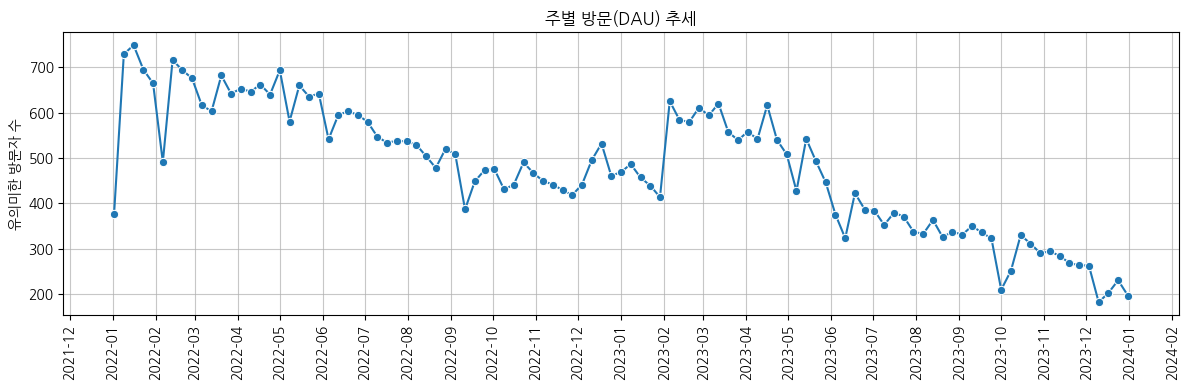

In [ ]:
visit_dau = for_visit_stay_time.groupby('date').size()
visit_dau.index = pd.to_datetime(visit_dau.index)

# 주간 평균으로 부드럽게 보고 싶다면
visit_dau_weekly = visit_dau.resample('W').mean()

# 라인 차트 그리기
plt.figure(figsize=(12, 4))

# seaborn lineplot
sns.lineplot(x=visit_dau_weekly.index, y=visit_dau_weekly.values, marker='o')

# x축 한 달 단위로 눈금 설정
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)
plt.title('주별 방문(DAU) 추세')
plt.ylabel('유의미한 방문자 수')
plt.xlabel('')
plt.tight_layout()
plt.grid(alpha=0.7)
plt.show()

In [ ]:
# visit_dau.to_csv('일별 방문자수.csv')

#### 신규 가입자 재방문율

In [ ]:
signup_date_map = signup_done_v4.set_index('user_uuid')['date']

# for_visit_stay_time에 가입일 매핑
fvt = for_visit_stay_time.copy()
fvt['signup_date'] = fvt['user_uuid'].map(signup_date_map)

# 가입 유저이면서, 방문일이 가입일 이후(또는 당일)인 로우만
fvt_filtered = fvt.loc[fvt['signup_date'].notna() & (fvt['date'] >= fvt['signup_date'])].drop(columns='signup_date')

In [ ]:
first_dates = fvt_filtered.groupby('user_uuid')['date'].min().rename('first_date').to_frame()

df = fvt_filtered.merge(first_dates, on='user_uuid')

# 코호트 월, 활성 월, 경과 개월수 계산
df['cohort_month'] = df['first_date'].dt.to_period('M')
df['active_month'] = df['date'].dt.to_period('M')
df['period_index'] = (df['active_month'].dt.year  - df['cohort_month'].dt.year) * 12 + (df['active_month'].dt.month - df['cohort_month'].dt.month)

# 코호트 크기(기간 0)와 유저 수 집계
cohort_sizes = df[df['period_index']==0].groupby('cohort_month')['user_uuid'].nunique()

# 월별 리텐션 계산(%)
retention = (df.groupby(['cohort_month','period_index'])['user_uuid'].nunique().unstack(fill_value=0).div(cohort_sizes, axis=0).multiply(100))

# 2022년·2023년 코호트만 필터링
retention_2022 = retention[retention.index.year == 2022]
retention_2023 = retention[retention.index.year == 2023]

In [ ]:
# retention.to_csv('신규 가입자 재방문율.csv')

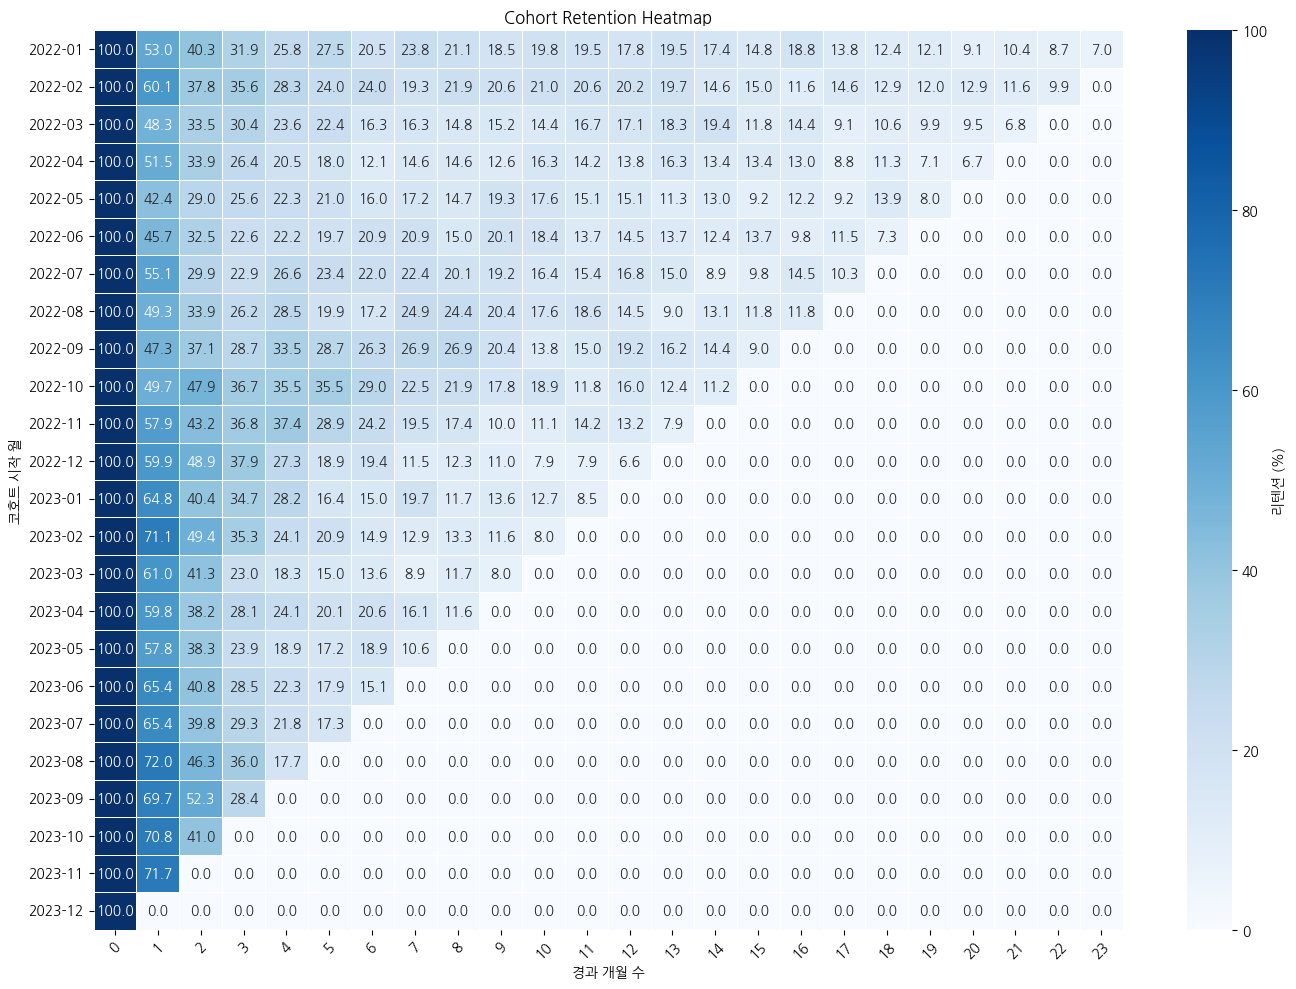

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    retention,                  # cohort DataFrame
    cmap='Blues',               # 푸른 계열 컬러맵
    annot=True,                 # 셀 안에 값 표시
    fmt='.1f',                  # 소수 첫째 자리까지 포맷
    linewidths=0.5,             # 셀 경계
    cbar_kws={'label':'리텐션 (%)'}  # 컬러바 라벨
)
plt.title('Cohort Retention Heatmap')
plt.xlabel('경과 개월 수')
plt.ylabel('코호트 시작 월')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("2022 코호트 리텐션")
retention_2022.round(1)

2022 코호트 리텐션


period_index,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort_month,,,,,,,,,,,,,,,,,,,,,
2022-01,100.0,53.0,40.3,31.9,25.8,27.5,20.5,23.8,21.1,18.5,...,17.4,14.8,18.8,13.8,12.4,12.1,9.1,10.4,8.7,7.0
2022-02,100.0,60.1,37.8,35.6,28.3,24.0,24.0,19.3,21.9,20.6,...,14.6,15.0,11.6,14.6,12.9,12.0,12.9,11.6,9.9,0.0
2022-03,100.0,48.3,33.5,30.4,23.6,22.4,16.3,16.3,14.8,15.2,...,19.4,11.8,14.4,9.1,10.6,9.9,9.5,6.8,0.0,0.0
2022-04,100.0,51.5,33.9,26.4,20.5,18.0,12.1,14.6,14.6,12.6,...,13.4,13.4,13.0,8.8,11.3,7.1,6.7,0.0,0.0,0.0
2022-05,100.0,42.4,29.0,25.6,22.3,21.0,16.0,17.2,14.7,19.3,...,13.0,9.2,12.2,9.2,13.9,8.0,0.0,0.0,0.0,0.0
2022-06,100.0,45.7,32.5,22.6,22.2,19.7,20.9,20.9,15.0,20.1,...,12.4,13.7,9.8,11.5,7.3,0.0,0.0,0.0,0.0,0.0
2022-07,100.0,55.1,29.9,22.9,26.6,23.4,22.0,22.4,20.1,19.2,...,8.9,9.8,14.5,10.3,0.0,0.0,0.0,0.0,0.0,0.0
2022-08,100.0,49.3,33.9,26.2,28.5,19.9,17.2,24.9,24.4,20.4,...,13.1,11.8,11.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-09,100.0,47.3,37.1,28.7,33.5,28.7,26.3,26.9,26.9,20.4,...,14.4,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print("\n2023 코호트 리텐션")
retention_2023.iloc[:, :12].round(1)


2023 코호트 리텐션


period_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2023-01,100.0,64.8,40.4,34.7,28.2,16.4,15.0,19.7,11.7,13.6,12.7,8.5
2023-02,100.0,71.1,49.4,35.3,24.1,20.9,14.9,12.9,13.3,11.6,8.0,0.0
2023-03,100.0,61.0,41.3,23.0,18.3,15.0,13.6,8.9,11.7,8.0,0.0,0.0
2023-04,100.0,59.8,38.2,28.1,24.1,20.1,20.6,16.1,11.6,0.0,0.0,0.0
2023-05,100.0,57.8,38.3,23.9,18.9,17.2,18.9,10.6,0.0,0.0,0.0,0.0
2023-06,100.0,65.4,40.8,28.5,22.3,17.9,15.1,0.0,0.0,0.0,0.0,0.0
2023-07,100.0,65.4,39.8,29.3,21.8,17.3,0.0,0.0,0.0,0.0,0.0,0.0
2023-08,100.0,72.0,46.3,36.0,17.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09,100.0,69.7,52.3,28.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 지원 리텐션

#### 일별 지원자 수(DAU)

In [ ]:
apply_dau = log_session[log_session['URL'].str.contains('api/jobs/id/apply/step4')]

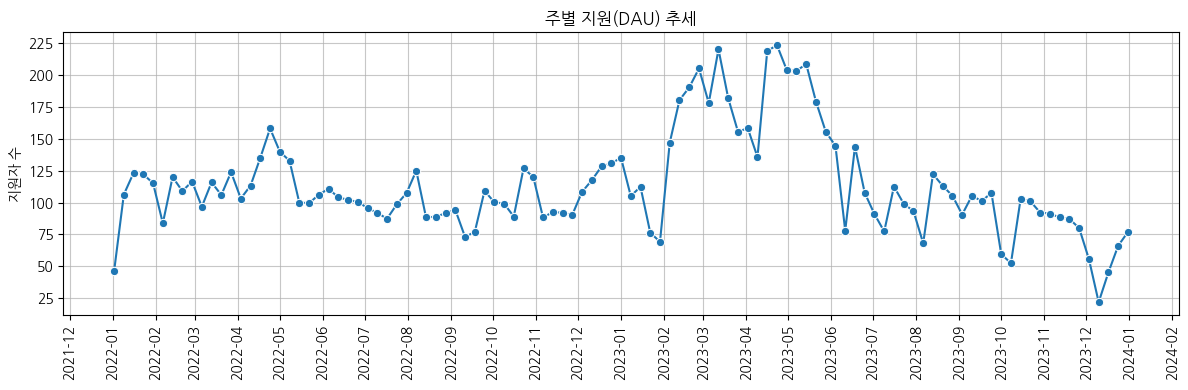

In [ ]:
apply_dau = apply_dau.groupby('date').size()
apply_dau.index = pd.to_datetime(apply_dau.index)

# 주간 평균으로 부드럽게 보고 싶다면
apply_dau_weekly = apply_dau.resample('W').mean()

# 라인 차트 그리기
plt.figure(figsize=(12, 4))

# seaborn lineplot
sns.lineplot(x=apply_dau_weekly.index, y=apply_dau_weekly.values, marker='o')

# x축 한 달 단위로 눈금 설정
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)
plt.title('주별 지원(DAU) 추세')
plt.ylabel('지원자 수')
plt.xlabel('')
plt.tight_layout()
plt.grid(alpha=0.7)
plt.show()

In [ ]:
# apply_dau.to_csv('일별 지원자수.csv')

#### 신규 가입자 재지원율

In [ ]:
new_user = pd.DataFrame(signup_done_v4['user_uuid'].unique(), columns=['user_uuid'])

In [ ]:
new_user_log_session = log_session[log_session['user_uuid'].isin(new_user['user_uuid'].unique())]

In [ ]:
signup_first = signup_done_v4.groupby('user_uuid')['timestamp'].min()

# map으로 new_user_log_session에 붙이기
new_user_log_session['signup_date'] = (new_user_log_session['user_uuid'].map(signup_first))

In [ ]:
new_user_log_session['deadline'] = new_user_log_session['signup_date'] + pd.Timedelta(days=3)

# 가입일 당일부터 7일 이내 로그만 필터링
mask1 = (new_user_log_session['timestamp'] >= new_user_log_session['signup_date']) & (new_user_log_session['timestamp'] <= new_user_log_session['deadline'])
new_user_log_session_7d = new_user_log_session.loc[mask1].drop(columns='deadline')

# 가입일 당일부터 7일 이후 로그만 필터링
mask2 = new_user_log_session['timestamp'] > new_user_log_session['deadline']
new_user_log_session_7d_after = new_user_log_session.loc[mask2].drop(columns='deadline')

In [ ]:
# 신규 유저 가운데 가입 후 7일 이내 지원한 경우
new_user_apply_7d = new_user_log_session_7d[new_user_log_session_7d['URL'].str.contains('api/jobs/id/apply/step4')]
new_user_apply_7d_count = pd.DataFrame(new_user_apply_7d.groupby('user_uuid').size().reset_index())
new_user_apply_7d_count.columns = ['user_uuid', 'apply_count']
new_user_apply_7d_count = pd.merge(new_user, new_user_apply_7d_count, how='left', on='user_uuid')
new_user_apply_7d_count = new_user_apply_7d_count.fillna(0)
new_user_apply_7d_count['apply_count'] = new_user_apply_7d_count['apply_count'].astype('int32')

In [ ]:
# 가입 후 7일 이내 3회 이상 지원한 유저 비율
len(new_user_apply_7d_count[new_user_apply_7d_count['apply_count'] != 0]) / len(new_user)

0.31498079385403327

In [ ]:
apply_7d = new_user_apply_7d_count[new_user_apply_7d_count['apply_count'] != 0]['user_uuid'].unique()
not_apply_7d = new_user_apply_7d_count[new_user_apply_7d_count['apply_count'] == 0]['user_uuid'].unique()

In [ ]:
# 가입 후 7일 이내 지원한 유저의 가입 후 7일 이후의 로그
after_7d_apply_log = new_user_log_session_7d_after[new_user_log_session_7d_after['user_uuid'].isin(apply_7d)]

In [ ]:
apply_stay_time = after_7d_apply_log.groupby(['user_uuid', 'date', 'session_num']).agg({'diff_seconds': 'sum'}).reset_index()
apply_stay_time = apply_stay_time[apply_stay_time['diff_seconds'] >= 120]

In [ ]:
# 평균 방문(7일 이내 지원함)
np.mean(apply_stay_time.groupby('user_uuid').size())

22.856560717196412

In [ ]:
len(apply_stay_time.groupby('user_uuid').size()) / len(apply_7d)

0.8313008130081301

In [ ]:
# 평균 지원(7일 이내 3회 이상 지원)
np.mean(after_7d_apply_log[after_7d_apply_log['URL'].str.contains('api/jobs/id/apply/step4')].groupby('user_uuid').size())

8.83578947368421

In [ ]:
# 재지원율
len(after_7d_apply_log[after_7d_apply_log['URL'].str.contains('api/jobs/id/apply/step4')].groupby('user_uuid').size()) / len(apply_7d)

0.3218157181571816

In [ ]:
# 가입 후 7일 이내 지원하지 않은 유저의 가입 후 7일 이후의 로그
after_7d_not_apply_log = new_user_log_session_7d_after[new_user_log_session_7d_after['user_uuid'].isin(not_apply_7d)]

In [ ]:
not_apply_stay_time = after_7d_not_apply_log.groupby(['user_uuid', 'date', 'session_num']).agg({'diff_seconds': 'sum'}).reset_index()
not_apply_stay_time = not_apply_stay_time[not_apply_stay_time['diff_seconds'] >= 120]

In [ ]:
# 평균 방문(7일 이내 지원하지 않음)
np.mean(not_apply_stay_time.groupby('user_uuid').size())

43.96673003802282

In [ ]:
# 7일 이내 지원하지 않은 사용자들의 재방문율
len(not_apply_stay_time.groupby('user_uuid').size()) / len(not_apply_7d)

0.983177570093458

In [ ]:
# 평균 지원(7일 이내 지원하지 않음)
# 300번 이상 지원은 이상치로 판단
after_7d_not_apply_log = after_7d_not_apply_log[after_7d_not_apply_log['user_uuid'] != '29b83f20-9293-4856-a674-22996ba75452']
np.mean(after_7d_not_apply_log[after_7d_not_apply_log['URL'].str.contains('api/jobs/id/apply/step4')].groupby('user_uuid').size())

7.512743125419182

In [ ]:
# 재지원율
len(after_7d_not_apply_log[after_7d_not_apply_log['URL'].str.contains('api/jobs/id/apply/step4')].groupby('user_uuid').size()) / len(not_apply_7d)

0.9289719626168225

# 7. EDA 및 지표를 통한 현황 진단
- 현 플랫폼의 주 사용자층은 IT 업계 이직 준비자로 파악되며,
IT 업계는 빠르게 변화하는 특성이 있어,
사용자들이 원하는 기업의 공고가 빠르고 다양하게
제공될수록 지원 유입이 촉진될 것으로 판단

- 현 로그에서는 지원자의 최종 합격 여부를 파악할 수 없어,
유저가 “얼마나 많이 지원하는지”를 플랫폼 활성화의 핵심 지표로 선정

- EDA와 로그 데이터를 통해 AARRR 프레임워크의
주요 지표를 점검한 결과, 대부분의 단계에서 이용 추세가
지속적으로 하락하고 있음을 확인

- 특히 핵심 지표로 선정한 지원 횟수와 관련된
Activation(지원 시도)와 Retention(재지원) 단계에서의
이탈이 크게 발생해  플랫폼 성장을 위해
긴급한 개선이 필요한 상태로 판단

# 8. 분석 심화
- 목표 설정
    - 거시 목표: 사용자당 지원 횟수 상승으로 플랫폼 활성화 촉진
    - 미시 목표: 20회 이상 지원 사용자 그룹을 “충성 고객”으로 정의하고, 이들의 주요 행동 패턴을 분석하여 그 외 유저들의 행동 변화 유도 
- 우선순위 선정 및 실행 전략
    - 예측 모델링: 지원 예측 분류 모델을 구축하여 80% 이상의 확률로 충성 고객일 사용자 그룹 식별
    - 행동 패턴 분석: 충성 고객 그룹의 상위 피처
    - 맞춤형 행동 유도: 피처 중요도에 따른 개선 우선 순위 적용
    - 단계적 개선: 모든 영역 동시 개선이 불가하므로 우선순위 기반으로 소규모 실험 → 효과 검증 → 점진적 확대

In [ ]:
all_user = pd.DataFrame(log_session['user_uuid'].unique(), columns=['user_uuid'])

In [ ]:
# 현재 플랫폼 유저(지원 경험이 있는)들의 평균 지원 횟수
np.mean(log_session[log_session['URL'].str.contains('api/jobs/id/apply/step4')].groupby('user_uuid').size())

8.155873420201821

In [ ]:
# 지원 횟수 카운트
apply_count = pd.DataFrame(log_session[log_session['URL'].str.contains('api/jobs/id/apply/step4')].groupby('user_uuid').size())
apply_count = apply_count.reset_index()
apply_count.columns = ['user_uuid', 'count']

In [ ]:
# 20번 이상 지원한 경우 label 컬럼의 값을 1, 그렇지 않은 경우 0
apply_count = pd.merge(all_user, apply_count, how='left', on='user_uuid').fillna(0)
apply_count['count'] = apply_count['count'].astype('int32')
apply_count['label'] = apply_count['count'].apply(lambda row: 1 if row >=20 else 0)

In [ ]:
# 전체 유저 중 20번 이상 지원한 유저의 비율
sum(apply_count['label'] == 1) / len(apply_count)

0.039154084216449406

## 피처 선택
- 총 방문 횟수, 총 세션 수, 평균 체류 시간, 총 체류 시간, 세션 간 평균 간격, 채용공고 페이지 평균 체류 시간, 채용공고 확인 수, 북마크 횟수, 검색 횟수, 지원시도 횟수

In [ ]:
data = apply_count.copy()

### 총 방문 수
- 단순 방문인 유저는 제외

In [ ]:
visit = for_visit_stay_time[~for_visit_stay_time[['user_uuid', 'date']].duplicated()]

In [ ]:
total_visit = pd.DataFrame(visit.groupby('user_uuid').size()).reset_index()

In [ ]:
total_visit.columns = ['user_uuid', 'total_visit']

In [ ]:
total_visit

,user_uuid,total_visit
0,0002535c-eacb-456b-a620-92c917332ba3,4
1,000681b4-bb66-4ccf-9786-f0066d13a34e,2
2,000b55ad-5c86-438b-a5b0-9ea3a2917789,10
3,000d53f7-5ddd-48ba-8dab-bb77b157e13a,2
4,000e8610-16d3-4e9e-bf50-202d191ffac4,15
...,...,...
18934,fff082bd-c063-4d10-be2d-b2b53f54527e,1
18935,fff3440e-7c0a-485b-a392-c41023060e96,3
18936,fff45252-3c40-4805-99e9-6b650c1fca80,5
18937,fff8a5c0-c85b-4e30-a22d-ed61b4480615,2


In [ ]:
# 데이터 병합
data = pd.merge(total_visit, data, how='left', on='user_uuid')

In [ ]:
# 전체 유저 중 20번 이상 지원한 유저의 비율
sum(data['label'] == 1) / len(data)

0.04408891704947463

### 총 세션 수

In [ ]:
total_session = pd.DataFrame(for_visit_stay_time.groupby('user_uuid').size()).reset_index()

In [ ]:
total_session.columns = ['user_uuid', 'total_session']

In [ ]:
total_session

,user_uuid,total_session
0,0002535c-eacb-456b-a620-92c917332ba3,4
1,000681b4-bb66-4ccf-9786-f0066d13a34e,2
2,000b55ad-5c86-438b-a5b0-9ea3a2917789,14
3,000d53f7-5ddd-48ba-8dab-bb77b157e13a,2
4,000e8610-16d3-4e9e-bf50-202d191ffac4,17
...,...,...
18934,fff082bd-c063-4d10-be2d-b2b53f54527e,1
18935,fff3440e-7c0a-485b-a392-c41023060e96,4
18936,fff45252-3c40-4805-99e9-6b650c1fca80,6
18937,fff8a5c0-c85b-4e30-a22d-ed61b4480615,4


In [ ]:
# 데이터 병합
data = pd.merge(data, total_session, how='left', on='user_uuid')

### 평균 체류 시간
- 분으로 통일

In [ ]:
mean_stay_time = for_visit_stay_time.groupby(['user_uuid']).agg({'diff_seconds': 'mean'}).reset_index()

In [ ]:
mean_stay_time.columns = ['user_uuid', 'mean_stay_time']

In [ ]:
mean_stay_time['mean_stay_time'] = np.round(mean_stay_time['mean_stay_time'] / 60, 2)

In [ ]:
# 데이터 병합
data = pd.merge(data, mean_stay_time, how='left', on='user_uuid')

### 총 체류 시간

In [ ]:
total_stay_time = for_visit_stay_time.groupby(['user_uuid']).agg({'diff_seconds': 'sum'}).reset_index()

In [ ]:
total_stay_time.columns = ['user_uuid', 'total_stay_time']

In [ ]:
total_stay_time['total_stay_time'] = np.round(total_stay_time['total_stay_time'] / 60, 2)

In [ ]:
# 데이터 병합
data = pd.merge(data, total_stay_time, how='left', on='user_uuid')

### 세션간 평균 간격
- 얼마나 자주 플랫폼을 이용하는지 파악
- 해당 값이 없는 유저는 한 번만 방문했을 것임

In [ ]:
keys = for_visit_stay_time[['user_uuid','date','session_num']]

In [ ]:
new_session = log_session[log_session['new_session'] == True]
new_session = pd.merge(new_session, keys, on=['user_uuid','date','session_num'], how='inner')

In [ ]:
new_session

,user_uuid,URL,timestamp,date,response_code,method,prev_ts,diff_seconds,diff_hours,new_session,session_num
0,0002535c-eacb-456b-a620-92c917332ba3,password_reset?code=7405ee4d-f1b6-4655-891d-0f...,2022-06-08 06:18:45,2022-06-08,200,GET,2022-05-27 06:59:14,1034371.0,287.325278,True,6
1,0002535c-eacb-456b-a620-92c917332ba3,continue?next=/jobs/131826/apply/step1&token=D...,2022-07-23 04:06:03,2022-07-23,302,GET,2022-06-22 23:01:18,2610285.0,725.079167,True,11
2,0002535c-eacb-456b-a620-92c917332ba3,jobs,2022-08-01 03:53:13,2022-08-01,200,GET,2022-07-23 04:13:18,776395.0,215.665278,True,12
3,0002535c-eacb-456b-a620-92c917332ba3,jobs/id/apply/step1,2022-10-19 01:31:13,2022-10-19,200,GET,2022-10-06 08:58:37,1096356.0,304.543333,True,17
4,000d53f7-5ddd-48ba-8dab-bb77b157e13a,companies,2022-02-17 02:10:51,2022-02-17,200,GET,NaT,NaN,NaN,True,1
...,...,...,...,...,...,...,...,...,...,...,...
343901,ffff25ca-c1d7-4fc2-891b-b0df92f95092,jobs,2023-11-29 14:06:21,2023-11-29,200,GET,2023-11-27 11:39:42,181599.0,50.444167,True,81
343902,ffff25ca-c1d7-4fc2-891b-b0df92f95092,companies/company_id/jobs,2023-12-04 11:14:19,2023-12-04,200,GET,2023-11-29 14:26:07,420492.0,116.803333,True,82
343903,ffff25ca-c1d7-4fc2-891b-b0df92f95092,jobs,2023-12-05 12:03:15,2023-12-05,200,GET,2023-12-04 12:55:40,83255.0,23.126389,True,84
343904,ffff25ca-c1d7-4fc2-891b-b0df92f95092,jobs/id/id_title,2023-12-15 13:53:29,2023-12-15,200,GET,2023-12-05 12:21:01,869548.0,241.541111,True,85


In [ ]:
# 같은 유저 내에서 다음 세션 시작 시각을 shift 로 얻기
new_session['next_ts'] = new_session.groupby('user_uuid')['timestamp'].shift(-1)

# 세션 간격(interval) 계산(초 단위)
new_session['session_gap_min'] = (new_session['next_ts'] - new_session['timestamp']).dt.total_seconds() / 60

# 마지막 세션(다음 ts가 NaT)은 빼고, 유저별 평균 세션 간격 구하기
avg_gap = new_session.loc[new_session['session_gap_min'].notna()].groupby('user_uuid')['session_gap_min'].mean().reset_index(name='avg_session_gap')
avg_gap['avg_session_gap'] = np.round(avg_gap['avg_session_gap'], 2)

In [ ]:
avg_gap

,user_uuid,avg_session_gap
0,0002535c-eacb-456b-a620-92c917332ba3,63744.16
1,000681b4-bb66-4ccf-9786-f0066d13a34e,2980.93
2,000b55ad-5c86-438b-a5b0-9ea3a2917789,5426.48
3,000d53f7-5ddd-48ba-8dab-bb77b157e13a,55279.92
4,000e8610-16d3-4e9e-bf50-202d191ffac4,42040.92
...,...,...
15808,ffee959d-51e1-41d1-b662-1e55c7c379bf,142.68
15809,fff3440e-7c0a-485b-a392-c41023060e96,40035.66
15810,fff45252-3c40-4805-99e9-6b650c1fca80,30591.90
15811,fff8a5c0-c85b-4e30-a22d-ed61b4480615,7737.28


In [ ]:
# 데이터 병합
data = pd.merge(data, avg_gap, how='left', on='user_uuid')
data = data.fillna(0)

In [ ]:
bins   = [-1, 0, 1440, 4320, 10080, 43200, np.inf]
labels = [
    'Single visit',  # 0
    'under 1 day',   # 1~1440분
    '1-3 days',      # 1440~4320분
    '3-7 days',      # 4320~10080분
    '7-30 days',     # 10080~43200분
    'over 30 days'   # 43200분~
]

# pd.cut 으로 카테고리화
data['avg_gap_cat'] = pd.cut(data['avg_session_gap'], bins=bins, labels=labels)

### 채용공고 확인 수

In [ ]:
total_view_apply = apply_page_dwell_time_result.groupby('user_uuid').size().reset_index()

In [ ]:
total_view_apply.columns = ['user_uuid', 'total_view_apply']

In [ ]:
# 데이터 병합
data = pd.merge(data, total_view_apply, how='left', on='user_uuid')

In [ ]:
data['total_view_apply'] = data['total_view_apply'].fillna(0).astype('int32')

### 채용공고 페이지 평균 체류 시간

In [ ]:
avg_stay_apply_page = apply_page_dwell_time_result.groupby('user_uuid').agg({'avg_dwell_time': 'mean'}).reset_index()

In [ ]:
avg_stay_apply_page.columns = ['user_uuid', 'avg_stay_apply_page']

In [ ]:
# 데이터 병합
data = pd.merge(data, avg_stay_apply_page, how='left', on='user_uuid')

In [ ]:
data['avg_stay_apply_page'] = np.round((data['avg_stay_apply_page'] / 60).fillna(0), 2)

### 이력서 수정/저장 횟수
- 'api/users/id/resume/step2' 이력서 수정/저장

In [ ]:
log_session_v1 = pd.merge(log_session, keys, on=['user_uuid','date','session_num'], how='inner')

In [ ]:
total_resume = log_session_v1[log_session_v1['URL'].str.contains('api/users/id/resume/step2')]

In [ ]:
total_resume = total_resume.groupby('user_uuid').size().reset_index()

In [ ]:
total_resume.columns = ['user_uuid', 'total_resume']

In [ ]:
# 데이터 병합
data = pd.merge(data, total_resume, how='left', on='user_uuid')

In [ ]:
data['total_resume'] = data['total_resume'].fillna(0).astype('int32')

### 검색 횟수
- 'search?keywords=': 통합 검색
- 'jobs?keywords=': 직무 검색
- 'companies?keywords=': 회사 검색

In [ ]:
search_condition = (
    (~log_session_v1['URL'].str.contains('api'))
    & ((log_session_v1['URL'].str.contains('search')) | (log_session_v1['URL'].str.contains('jobs')) | (log_session_v1['URL'].str.contains('companies')))
    & (log_session_v1['URL'].str.contains('keywords'))
)

In [ ]:
search_log = log_session_v1[search_condition]

In [ ]:
# 전체 검색 분포
search_log[search_log['URL'].str.contains('search')]['URL'].value_counts()

URL
search?keywords=프론트엔드       1799
search?keywords=flutter     1598
search?keywords=블록체인         555
search?keywords=ios          516
search?keywords=django       501
                            ... 
search?keywords=한지흔            1
search?keywords=류종찬            1
search?keywords=박근우            1
search?keywords=키돕             1
search?keywords=frienkly       1
Name: count, Length: 27786, dtype: int64

In [ ]:
# 직무 검색 분포
search_log[search_log['URL'].str.contains('jobs')]['URL'].value_counts()

URL
jobs?page=&keywords=프론트엔드&career_type=1&q=    956
jobs?keywords=flutter&q=                      679
jobs?page=&keywords=안드로이드&q=                  508
jobs?keywords=flutter                         492
jobs?page=&keywords=안드로이드&career_type=1&q=    468
                                             ... 
jobs?keywords=드라마&q=                            1
jobs?job=3&keywords=부산                          1
jobs?keywords=프로그라운드&q=                         1
jobs?keywords=포크&q=                             1
jobs?keywords=front&keywords=프론트&page=20        1
Name: count, Length: 11763, dtype: int64

In [ ]:
# 기업 검색 분포
search_log[search_log['URL'].str.contains('companies')]['URL'].value_counts()

URL
companies?keywords=부산&q=                                66
companies?keywords=부산&sort=recent                       44
companies?keywords=강남구&location=서울특별시&page=6            33
companies?keywords=프론트엔드                                27
companies?keywords=강남구&location=서울특별시&page=9            25
                                                        ..
companies?keywords=mcn                                   1
companies?keywords=프론트엔드&location=서울특별시&location=경기도     1
companies?keywords=키보드&q=                                1
companies?keywords=펀드&tag=핀테크                            1
companies?keywords=프론트엔드+인턴                              1
Name: count, Length: 2180, dtype: int64

In [ ]:
# 유저별 검색 총 횟수
total_search_count = search_log.groupby('user_uuid').size().reset_index()
total_search_count.columns = ['user_uuid', 'total_search_count']
data = pd.merge(data, total_search_count, how='left', on='user_uuid')
data['total_search_count'] = data['total_search_count'].fillna(0).astype('int32')

In [ ]:
# 유저별 전체 검색 횟수
attempt_search = search_log[search_log['URL'].str.contains('search')].groupby('user_uuid').size().reset_index()
attempt_search.columns = ['user_uuid', 'attempt_search']
data = pd.merge(data, attempt_search, how='left', on='user_uuid')
data['attempt_search'] = data['attempt_search'].fillna(0).astype('int32')

In [ ]:
# 유저별 직무 검색 횟수
attempt_jobs = search_log[search_log['URL'].str.contains('jobs')].groupby('user_uuid').size().reset_index()
attempt_jobs.columns = ['user_uuid', 'attempt_jobs']
data = pd.merge(data, attempt_jobs, how='left', on='user_uuid')
data['attempt_jobs'] = data['attempt_jobs'].fillna(0).astype('int32')

In [ ]:
# 유저별 기업 검색 횟수
attempt_companies = search_log[search_log['URL'].str.contains('companies')].groupby('user_uuid').size().reset_index()
attempt_companies.columns = ['user_uuid', 'attempt_companies']
data = pd.merge(data, attempt_companies, how='left', on='user_uuid')
data['attempt_companies'] = data['attempt_companies'].fillna(0).astype('int32')

### 지원시도 횟수

In [ ]:
attempt_apply = log_session_v1[log_session_v1['URL'].str.contains('jobs/id/apply/step1')].groupby('user_uuid').size().reset_index()
attempt_apply.columns = ['user_uuid', 'attempt_apply']
data = pd.merge(data, attempt_apply, how='left', on='user_uuid')
data['attempt_apply'] = data['attempt_apply'].fillna(0).astype('int32')

## 분류 (Classification)
- 지원하는데 영향을 끼치는 요인(검색 횟수, 평균 세션 시간, 공고 페이지 체류시간 등등)을 파악하여 지원 여부를 판단하는 예측 모델 만들기
- 높은 확률로 지원하는 집단을 찾아내고 특징을 찾아내어 낮은 확률로 지원하는 집단의 행동 변화를 유도하는 전략 제시

- 총 방문 횟수(total_visit)
    : 플랫폼 진입 빈도를 나타냄. 방문 횟수가 많을수록 관심·활동 수준이 높아 지원 가능성이 높을 것이라고 판단.

- 총 세션 수(total_session)
    : 세션이 많다는 건 짧게라도 자주 돌아온다는 의미. 세션 수는 ‘재방문 의지’의 직관적 지표라고 판단.

- 평균 체류 시간(mean_stay_time)
    : 한 번 머문 시간의 평균. 길게 머무를수록 상세 살펴보기·준비 행위가 많아 지원 전환율과 연관될 것이라고 판단.

- 총 체류 시간(total_stay_time)
    : 누적 머문 시간. 플랫폼에 쏟은 전체 노력이 많을수록 지원 횟수도 많아질 가능성이 클 것이라고 판단.

- 세션 간 평균 간격(avg_gap_cat)
    : 짧은 간격일수록 꾸준히 활동함을 의미

- 채용공고 확인 수(total_view_apply)
    : 공고 상세 페이지(지원 페이지) 조회 횟수. 공고 열람이 많을수록 실제 지원으로 이어질 확률이 높을 것이라고 판단.

- 채용공고 페이지 평균 체류 시간(avg_stay_apply_page)
    : 공고 상세에서 머문 평균 시간. 길게 체류할수록 해당 채용 공고들이 마음에 들었고, 지원으로 이어지겠다는 판단

- 북마크 횟수(total_resume)
    : 이력서 저장·북마크 횟수. 북마크를 자주 할수록 ‘지원 의사’가 명확해 지원 시도로 연결될 가능성이 클 것이라고 판단.

- 총 검색 횟수(total_search_count)
    : 총(전체 , 직무, 기업 검색 합친 값) 검색 횟수. 많은 검색은 활발한 탐색 행동을 뜻하며, 지원 횟수와 상관관계가 높을 것이라고 판단.

- 전체 검색 횟수(attempt_search)
    : 키워드 입력을 통한 검색 시도 횟수로, 실제 관심 키워드로 탐색을 많이 해볼 수록 지원을 많이 할 것이라고 판단.

- 직무 검색 횟수(attempt_jobs)
    : 직무별 필터링·검색 클릭 횟수. 관심 직무가 명확할수록 지원 행동으로 이어지기 쉬울 것이라고 판단.

- 기업 검색 횟수(attempt_companies)
    : 기업별 채용목록·회사페이지 조회 횟수. 특정 기업에 집중하면 실제 지원 확률이 높아질 것이라고 판단.

- 지원 시도 횟수(attempt_apply)
    : apply/step1 진입 횟수. “지원 의지”를 보이는 피처라고 판단.

In [ ]:
X = data[['total_visit', 'total_session', 'mean_stay_time', 'total_stay_time',
          'avg_gap_cat', 'total_view_apply', 'avg_stay_apply_page', 'total_resume',
          'total_search_count', 'attempt_search', 'attempt_jobs', 'attempt_companies', 'attempt_apply']]

In [ ]:
X

,total_visit,total_session,mean_stay_time,total_stay_time,avg_gap_cat,total_view_apply,avg_stay_apply_page,total_resume,total_search_count,attempt_search,attempt_jobs,attempt_companies,attempt_apply
0,4,4,27.80,111.22,over 30 days,0,0.00,0,0,0,0,0,13
1,2,2,54.98,109.95,1-3 days,2,1.85,1,0,0,0,0,0
2,10,14,36.06,504.87,3-7 days,10,4.18,3,32,17,15,0,12
3,2,2,8.09,16.18,over 30 days,3,0.50,0,0,0,0,0,9
4,15,17,18.74,318.62,7-30 days,11,1.99,0,3,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18934,1,1,13.20,13.20,Single visit,1,0.45,0,0,0,0,0,0
18935,3,4,49.80,199.22,7-30 days,2,9.62,0,0,0,0,0,12
18936,5,6,17.76,106.57,7-30 days,6,4.31,0,1,1,0,0,4
18937,2,4,26.79,107.17,3-7 days,3,2.10,2,0,0,0,0,12


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18939 entries, 0 to 18938
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   total_visit          18939 non-null  int64   
 1   total_session        18939 non-null  int64   
 2   mean_stay_time       18939 non-null  float64 
 3   total_stay_time      18939 non-null  float64 
 4   avg_gap_cat          18939 non-null  category
 5   total_view_apply     18939 non-null  int32   
 6   avg_stay_apply_page  18939 non-null  float64 
 7   total_resume         18939 non-null  int32   
 8   total_search_count   18939 non-null  int32   
 9   attempt_search       18939 non-null  int32   
 10  attempt_jobs         18939 non-null  int32   
 11  attempt_companies    18939 non-null  int32   
 12  attempt_apply        18939 non-null  int32   
dtypes: category(1), float64(3), int32(7), int64(2)
memory usage: 1.2 MB


In [ ]:
y = data[['label']]

### 전처리

In [ ]:
# 원-핫 인코딩 진행
X_preprocessing = pd.get_dummies(X, columns=['avg_gap_cat'], prefix='avg_gap', dtype=int)

### 평가지표 함수

In [ ]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print("<오차 행렬>")
    print(confusion)
    print("<평가 지표>")
    print(f'정확도: {accuracy:.4f}')
    print(f'정밀도: {precision:.4f}')
    print(f'재현율: {recall:.4f}')
    print(f'F1: {f1:.4f}')
    print(f'AUC: {roc_auc:.4f}')

In [ ]:
# 정밀도-재현율 그래프
def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출. 
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)
    
    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

In [ ]:
# ROC 곡선 그래프
def roc_curve_plot(y_test , pred_proba_c1):
    # 임곗값에 따른 FPR, TPR 값을 반환 받음. 
    fprs , tprs , thresholds = roc_curve(y_test ,pred_proba_c1)

    # ROC Curve를 plot 곡선으로 그림. 
    plt.plot(fprs , tprs, label='ROC')
    # 가운데 대각선 직선을 그림. 
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    
    # FPR X 축의 Scale을 0.1 단위로 변경, X,Y 축명 설정등   
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR( 1 - Sensitivity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()

### 데이터 분리

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessing, y, test_size=0.2, random_state=26)

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=26)

### RandomForest

#### 베이스라인 모델

In [ ]:
rf_baseline = RandomForestClassifier(random_state=26)

In [ ]:
rf_baseline.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 26,
 'verbose': 0,
 'warm_start': False}

In [ ]:
rf_baseline.fit(X_train, y_train)

RandomForestClassifier(random_state=26)

In [ ]:
get_clf_eval(y_test, rf_baseline.predict(X_test), rf_baseline.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3600   27]
 [  30  131]]
<평가 지표>
정확도: 0.9850
정밀도: 0.8291
재현율: 0.8137
F1: 0.8213
AUC: 0.9949


#### 하이퍼 파라미터 튜닝

In [ ]:
rf_search_space = {'min_samples_split': hp.quniform('min_samples_split', 2, 50, 1),
                    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 20, 1),
                    'max_depth': hp.choice('max_depth', [None, hp.quniform('max_depth_int', 5, 20, 1)]),
                    'max_leaf_nodes': hp.quniform('max_leaf_nodes', 10, 100, 1)}

In [ ]:
def objective_func(search_space):
    md = search_space['max_depth']
    max_depth = None if md is None else int(md)

    rf_clf = RandomForestClassifier(min_samples_split = int(search_space['min_samples_split']),
                                    min_samples_leaf = int(search_space['min_samples_leaf']),
                                    max_depth = max_depth,
                                    max_leaf_nodes = int(search_space['max_leaf_nodes']))
    
    f1 = cross_val_score(rf_clf, X_train, y_train, scoring='f1', cv=3)

    return {'loss': -1 * np.mean(f1), 'status': STATUS_OK}

In [ ]:
trial_val = Trials()
rf_best = fmin(fn=objective_func,
               space=rf_search_space,
               algo=tpe.suggest,
               max_evals=50,
               trials=trial_val)

print('best:', rf_best)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 50/50 [01:36<00:00,  1.93s/trial, best loss: -0.8201033930010445]
best: {'max_depth': 0, 'max_leaf_nodes': 59.0, 'min_samples_leaf': 18.0, 'min_samples_split': 9.0}


In [ ]:
rf_hyper = RandomForestClassifier(n_estimators=500,
                                    max_depth=None,
                                    max_leaf_nodes=int(rf_best['max_leaf_nodes']),
                                    min_samples_leaf=int(rf_best['min_samples_leaf']),
                                    min_samples_split=int(rf_best['min_samples_split']),
                                    random_state=26)

In [ ]:
rf_hyper.fit(X_train, y_train)

RandomForestClassifier(max_leaf_nodes=59, min_samples_leaf=18,
                       min_samples_split=9, n_estimators=500, random_state=26)

In [ ]:
get_clf_eval(y_test, rf_hyper.predict(X_test), rf_hyper.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3604   23]
 [  25  136]]
<평가 지표>
정확도: 0.9873
정밀도: 0.8553
재현율: 0.8447
F1: 0.8500
AUC: 0.9954


#### 결과

In [ ]:
get_clf_eval(y_test, rf_hyper.predict(X_test), rf_hyper.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3604   23]
 [  25  136]]
<평가 지표>
정확도: 0.9873
정밀도: 0.8553
재현율: 0.8447
F1: 0.8500
AUC: 0.9954


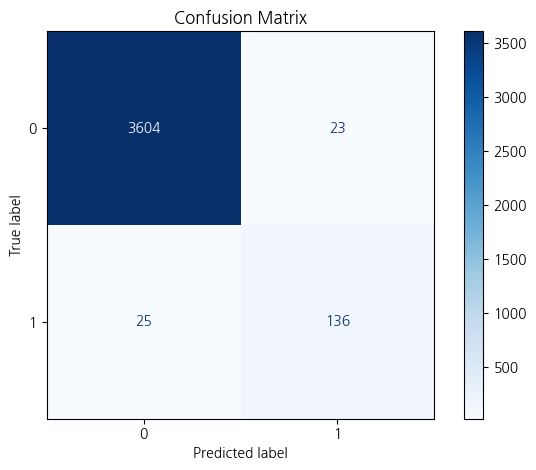

In [ ]:
# 오차행렬 시각화
cm = confusion_matrix(y_test, rf_hyper.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_hyper.classes_)

fig, ax = plt.subplots()

disp.plot(ax=ax, cmap='Blues')   # cmap='Blues' 추가

ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

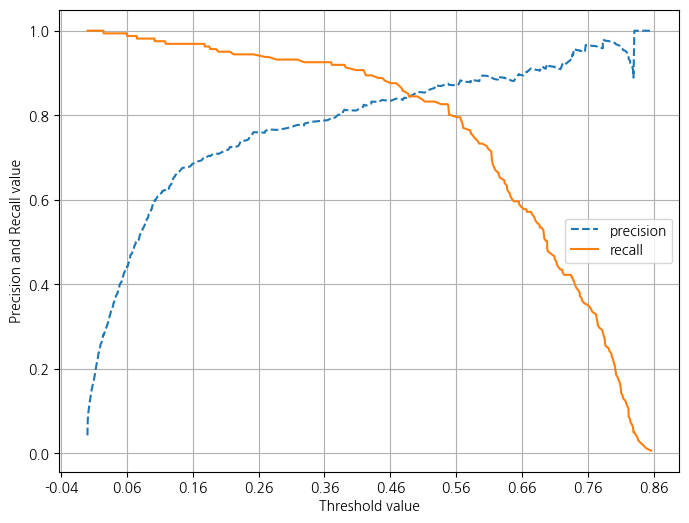

In [ ]:
# 정밀도-재현율 그래프
precision_recall_curve_plot(y_test, rf_hyper.predict_proba(X_test)[:, 1])

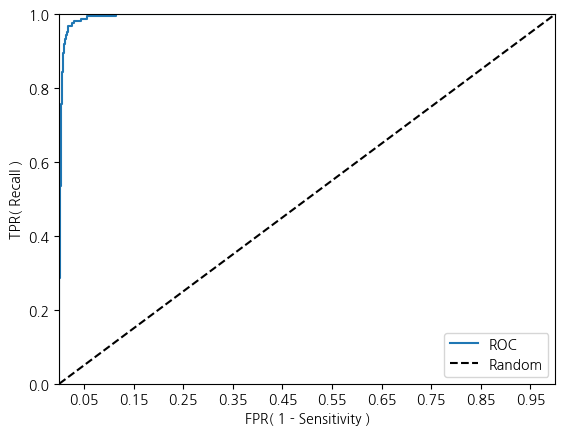

In [ ]:
# ROC-curve 그래프
roc_curve_plot(y_test, rf_hyper.predict_proba(X_test)[:, 1])

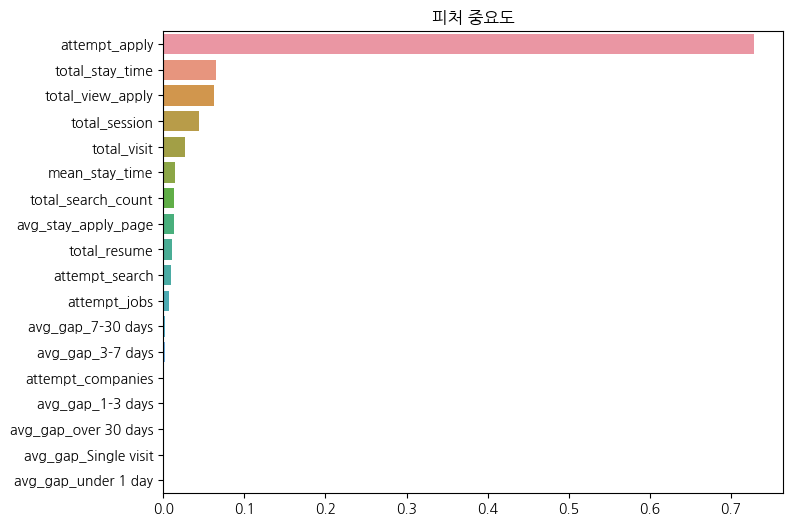

In [ ]:
# 피처 중요도 시각화
ftr_importances_values = rf_hyper.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.title('피처 중요도')

sns.barplot(x=ftr_importances, y=ftr_importances.index)

plt.show()

### XGBoost

#### 베이스라인 모델

In [ ]:
xgb_baseline = XGBClassifier(early_stopping_rounds=50, eval_metric='logloss', random_state=26)

In [ ]:
xgb_baseline.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': 50,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 26,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [ ]:
evals = [(X_tr, y_tr), (X_val, y_val)]

In [ ]:
xgb_baseline.fit(X_tr, y_tr, eval_set=evals)

[0]	validation_0-logloss:0.06653	validation_1-logloss:0.09215
[1]	validation_0-logloss:0.05312	validation_1-logloss:0.07736
[2]	validation_0-logloss:0.04512	validation_1-logloss:0.07099
[3]	validation_0-logloss:0.03926	validation_1-logloss:0.06517
[4]	validation_0-logloss:0.03544	validation_1-logloss:0.06208
[5]	validation_0-logloss:0.03218	validation_1-logloss:0.06065
[6]	validation_0-logloss:0.02980	validation_1-logloss:0.05894
[7]	validation_0-logloss:0.02805	validation_1-logloss:0.05732
[8]	validation_0-logloss:0.02631	validation_1-logloss:0.05663
[9]	validation_0-logloss:0.02496	validation_1-logloss:0.05600
[10]	validation_0-logloss:0.02397	validation_1-logloss:0.05527
[11]	validation_0-logloss:0.02324	validation_1-logloss:0.05546
[12]	validation_0-logloss:0.02227	validation_1-logloss:0.05453
[13]	validation_0-logloss:0.02164	validation_1-logloss:0.05396
[14]	validation_0-logloss:0.02093	validation_1-logloss:0.05384
[15]	validation_0-logloss:0.02042	validation_1-logloss:0.05454
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
get_clf_eval(y_test, xgb_baseline.predict(X_test), xgb_baseline.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3600   27]
 [  25  136]]
<평가 지표>
정확도: 0.9863
정밀도: 0.8344
재현율: 0.8447
F1: 0.8395
AUC: 0.9952


#### 하이퍼 파라미터 튜닝

In [ ]:
xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 30, 1),
                    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1)}

In [ ]:
def objective_func(search_space):
    xgb_clf = XGBClassifier(min_child_weight = int(search_space['min_child_weight']),
                            learning_rate = int(search_space['learning_rate']),
                            max_depth = int(search_space['max_depth']),
                            colsample_bytree = int(search_space['colsample_bytree']))
    
    f1 = cross_val_score(xgb_clf, X_train, y_train, scoring='f1', cv=3)

    return {'loss': -1 * np.mean(f1), 'status': STATUS_OK}

In [ ]:
trial_val = Trials()
xgb_best = fmin(fn=objective_func,
               space=xgb_search_space,
               algo=tpe.suggest,
               max_evals=50,
               trials=trial_val)

print('best:', xgb_best)

100%|██████████| 50/50 [00:15<00:00,  3.30trial/s, best loss: -0.0]
best: {'colsample_bytree': 0.5882160031318442, 'learning_rate': 0.019059963196902514, 'max_depth': 16.0, 'min_child_weight': 2.0}


In [ ]:
xgb_hyper = XGBClassifier(n_estimators=500,
                          max_depth=int(xgb_best['max_depth']),
                          colsample_bytree=xgb_best['colsample_bytree'],
                          learning_rate=xgb_best['learning_rate'],
                          min_child_weight=int(xgb_best['min_child_weight']),
                          early_stopping_rounds=100,
                          eval_metric='logloss',
                          random_state=26)

In [ ]:
xgb_hyper.fit(X_tr, y_tr, eval_set=evals)

[0]	validation_0-logloss:0.17475	validation_1-logloss:0.20759
[1]	validation_0-logloss:0.17134	validation_1-logloss:0.20431
[2]	validation_0-logloss:0.16012	validation_1-logloss:0.19114
[3]	validation_0-logloss:0.15147	validation_1-logloss:0.18125
[4]	validation_0-logloss:0.14436	validation_1-logloss:0.17298
[5]	validation_0-logloss:0.14191	validation_1-logloss:0.17053
[6]	validation_0-logloss:0.13617	validation_1-logloss:0.16406
[7]	validation_0-logloss:0.13109	validation_1-logloss:0.15834
[8]	validation_0-logloss:0.12919	validation_1-logloss:0.15648
[9]	validation_0-logloss:0.12741	validation_1-logloss:0.15477
[10]	validation_0-logloss:0.12555	validation_1-logloss:0.15313
[11]	validation_0-logloss:0.12149	validation_1-logloss:0.14848
[12]	validation_0-logloss:0.11778	validation_1-logloss:0.14429
[13]	validation_0-logloss:0.11438	validation_1-logloss:0.14044
[14]	validation_0-logloss:0.11299	validation_1-logloss:0.13916
[15]	validation_0-logloss:0.11159	validation_1-logloss:0.13806
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5882160031318442, device=None,
              early_stopping_rounds=100, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.019059963196902514,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=16, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
get_clf_eval(y_test, xgb_hyper.predict(X_test), xgb_hyper.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3605   22]
 [  30  131]]
<평가 지표>
정확도: 0.9863
정밀도: 0.8562
재현율: 0.8137
F1: 0.8344
AUC: 0.9951


#### 결과

In [ ]:
get_clf_eval(y_test, xgb_baseline.predict(X_test), xgb_baseline.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3600   27]
 [  25  136]]
<평가 지표>
정확도: 0.9863
정밀도: 0.8344
재현율: 0.8447
F1: 0.8395
AUC: 0.9952


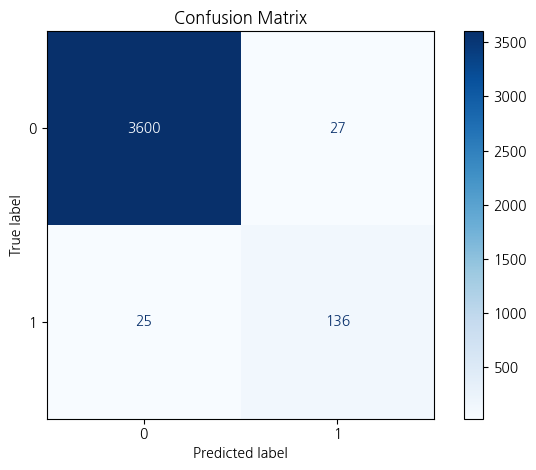

In [ ]:
# 오차행렬 시각화
cm = confusion_matrix(y_test, xgb_baseline.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_baseline.classes_)

fig, ax = plt.subplots()

disp.plot(ax=ax, cmap='Blues')   # cmap='Blues' 추가

ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

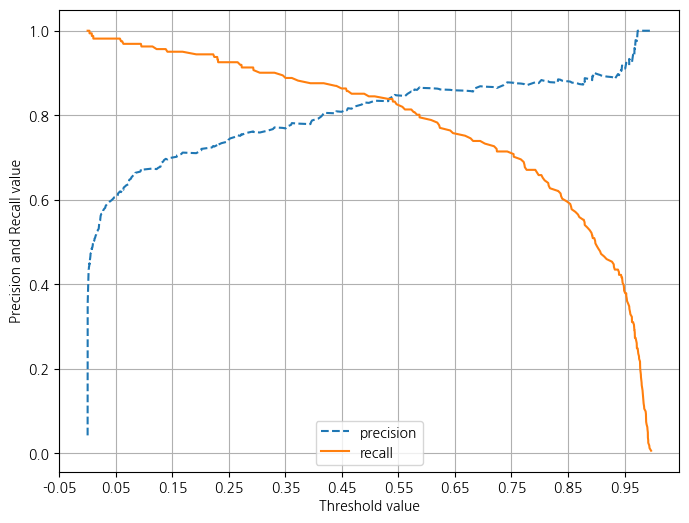

In [ ]:
# 정밀도-재현율 그래프
precision_recall_curve_plot(y_test, xgb_baseline.predict_proba(X_test)[:, 1])

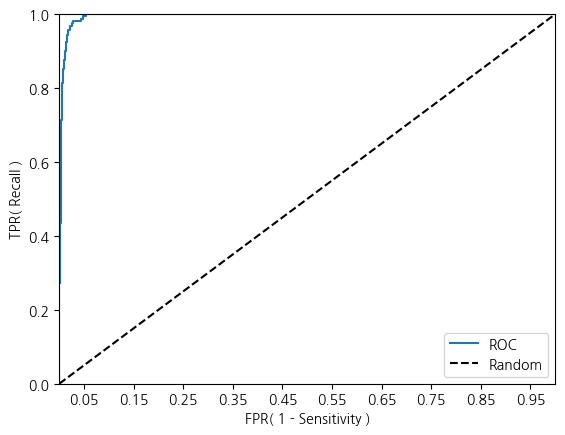

In [ ]:
# ROC-curve 그래프
roc_curve_plot(y_test, xgb_baseline.predict_proba(X_test)[:, 1])

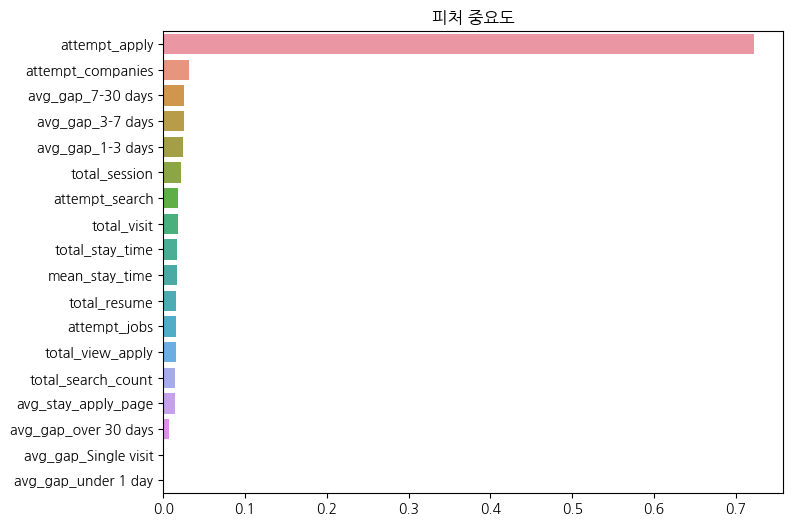

In [ ]:
# 피처 중요도 시각화
ftr_importances_values = xgb_baseline.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.title('피처 중요도')

sns.barplot(x=ftr_importances, y=ftr_importances.index)

plt.show()

### LGBM

#### 베이스라인 모델

In [ ]:
lgbm_baseline = LGBMClassifier(early_stopping_rounds=50, eval_metric='logloss', random_state=26)

In [ ]:
lgbm_baseline.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': -1,
 'num_leaves': 31,
 'objective': None,
 'random_state': 26,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'silent': 'warn',
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'early_stopping_rounds': 50,
 'eval_metric': 'logloss'}

In [ ]:
evals = [(X_tr, y_tr), (X_val, y_val)]

In [ ]:
lgbm_baseline.fit(X_tr, y_tr, eval_set=evals)

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[1]	training's binary_logloss: 0.106814	valid_1's binary_logloss: 0.133701
[2]	training's binary_logloss: 0.0929159	valid_1's binary_logloss: 0.118283
[3]	training's binary_logloss: 0.0825869	valid_1's binary_logloss: 0.107843
[4]	training's binary_logloss: 0.0742692	valid_1's binary_logloss: 0.0990257
[5]	training's binary_logloss: 0.0674211	valid_1's binary_logloss: 0.0926522
[6]	training's binary_logloss: 0.0616146	valid_1's binary_logloss: 0.0867067
[7]	training's binary_logloss: 0.0567042	valid_1's binary_logloss: 0.0820068
[8]	training's binary_logloss: 0.0523799	valid_1's binary_logloss: 0.0779844
[9]	training's binary_logloss: 0.0486087	valid_1's binary_logloss: 0.0737097
[10]	training's binary_logloss: 0.0452184	valid_1's binary_logloss: 0.0704698
[11]	training's binary_logloss: 0.0421481	valid

LGBMClassifier(early_stopping_rounds=50, eval_metric='logloss', random_state=26)

In [ ]:
get_clf_eval(y_test, lgbm_baseline.predict(X_test), lgbm_baseline.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3601   26]
 [  30  131]]
<평가 지표>
정확도: 0.9852
정밀도: 0.8344
재현율: 0.8137
F1: 0.8239
AUC: 0.9952


#### 하이퍼 파라미터 튜닝

In [ ]:
lgbm_search_space = {
    'num_leaves': hp.quniform('num_leaves', 32, 64, 1),
    'max_depth': hp.quniform('max_depth', 100, 160, 1),
    'min_child_samples': hp.quniform('min_child_samples', 60, 100, 1),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'feature_fraction': hp.uniform('feature_fraction', 0.5, 1.0),
    'bagging_freq': hp.quniform('bagging_freq', 1, 10, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0.0, 1.0),
    'max_bin': hp.quniform('max_bin', 100, 512, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
}

In [ ]:
def objective_func(search_space):
    lgbm_clf = LGBMClassifier(num_leaves = int(search_space['num_leaves']),
                              max_depth = int(search_space['max_depth']),
                              min_child_samples = int(search_space['min_child_samples']),
                              subsample = search_space['subsample'],
                              feature_fraction = search_space['feature_fraction'],
                              bagging_freq = int(search_space['bagging_freq']),
                              min_split_gain = search_space['min_split_gain'],
                              max_bin = int(search_space['max_bin']),
                              learning_rate = search_space['learning_rate']
                              )
    
    f1 = cross_val_score(lgbm_clf, X_train, y_train, scoring='f1', cv=3)

    return {'loss': -1 * np.mean(f1), 'status': STATUS_OK}

In [ ]:
trial_val = Trials()
lgbm_best = fmin(fn=objective_func,
               space=lgbm_search_space,
               algo=tpe.suggest,
               max_evals=50,
               trials=trial_val)

print('best:', lgbm_best)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

[LightGBM] [Warning] feature_fraction is set=0.999964471164057, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.999964471164057
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.999964471164057, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.999964471164057
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.999964471164057, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.999964471164057
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.9987771111970731, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9987771111970731
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will 

In [ ]:
lgbm_hyper = LGBMClassifier(n_estimators=500,
                          num_leaves = int(lgbm_best['num_leaves']),
                          max_depth = int(lgbm_best['max_depth']),
                          min_child_samples = int(lgbm_best['min_child_samples']),
                          subsample = lgbm_best['subsample'],
                          feature_fraction = lgbm_best['feature_fraction'],
                          bagging_freq = int(lgbm_best['bagging_freq']),
                          min_split_gain = lgbm_best['min_split_gain'],
                          max_bin = int(lgbm_best['max_bin']),
                          learning_rate = lgbm_best['learning_rate'],
                          early_stopping_rounds=100,
                          eval_metric='logloss',
                          random_state=26)

In [ ]:
lgbm_hyper.fit(X_tr, y_tr, eval_set=evals)

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] feature_fraction is set=0.9987771111970731, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9987771111970731
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[1]	training's binary_logloss: 0.0971947	valid_1's binary_logloss: 0.11965
[2]	training's binary_logloss: 0.0854236	valid_1's binary_logloss: 0.106147
[3]	training's binary_logloss: 0.0765054	valid_1's binary_logloss: 0.0961865
[4]	training's binary_logloss: 0.0693672	valid_1's binary_logloss: 0.0880897
[5]	training's binary_logloss: 0.0635948	valid_1's binary_logloss: 0.0820459
[6]	training's binary_logloss: 0.0587897	valid_1's binary_logloss: 0.0768543
[7]	training's binary_logloss: 0.0547702	valid_1's binary_logloss: 0.0729114
[8]	training'

LGBMClassifier(bagging_freq=3, early_stopping_rounds=100, eval_metric='logloss',
               feature_fraction=0.9987771111970731,
               learning_rate=0.12726768169547772, max_bin=274, max_depth=106,
               min_child_samples=86, min_split_gain=0.33767289201170536,
               n_estimators=500, num_leaves=56, random_state=26,
               subsample=0.873893149711746)

In [ ]:
get_clf_eval(y_test, lgbm_hyper.predict(X_test), lgbm_hyper.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3597   30]
 [  28  133]]
<평가 지표>
정확도: 0.9847
정밀도: 0.8160
재현율: 0.8261
F1: 0.8210
AUC: 0.9952


#### 결과

In [ ]:
get_clf_eval(y_test, lgbm_hyper.predict(X_test), lgbm_hyper.predict_proba(X_test)[:, 1])

<오차 행렬>
[[3597   30]
 [  28  133]]
<평가 지표>
정확도: 0.9847
정밀도: 0.8160
재현율: 0.8261
F1: 0.8210
AUC: 0.9952


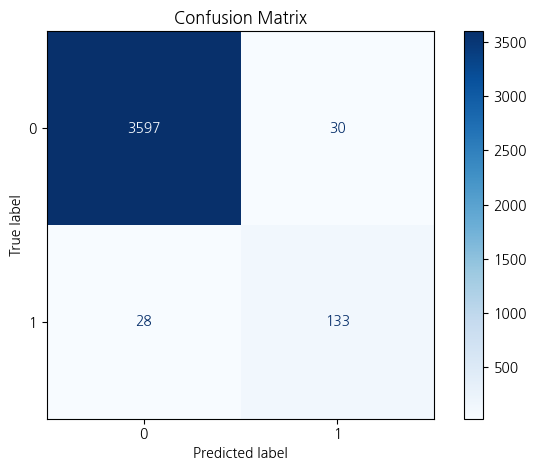

In [ ]:
# 오차행렬 시각화
cm = confusion_matrix(y_test, lgbm_hyper.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lgbm_hyper.classes_)

fig, ax = plt.subplots()

disp.plot(ax=ax, cmap='Blues')   # cmap='Blues' 추가

ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

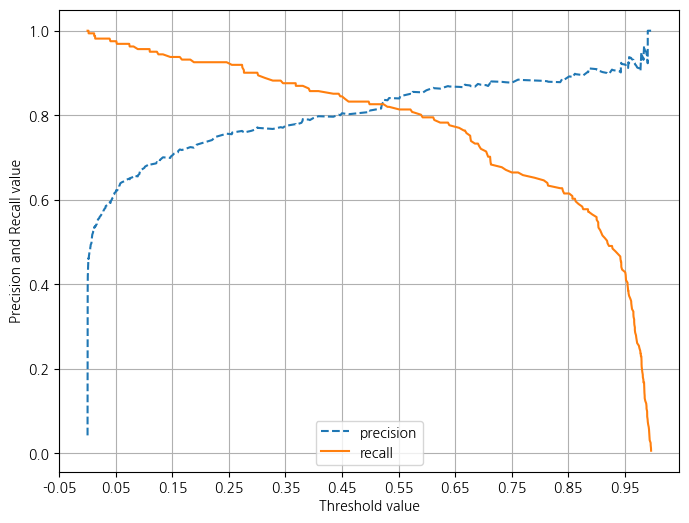

In [ ]:
# 정밀도-재현율 그래프
precision_recall_curve_plot(y_test, lgbm_hyper.predict_proba(X_test)[:, 1])

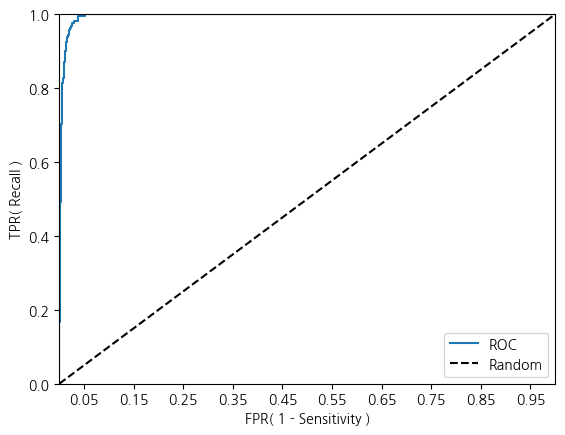

In [ ]:
# ROC-curve 그래프
roc_curve_plot(y_test, lgbm_hyper.predict_proba(X_test)[:, 1])

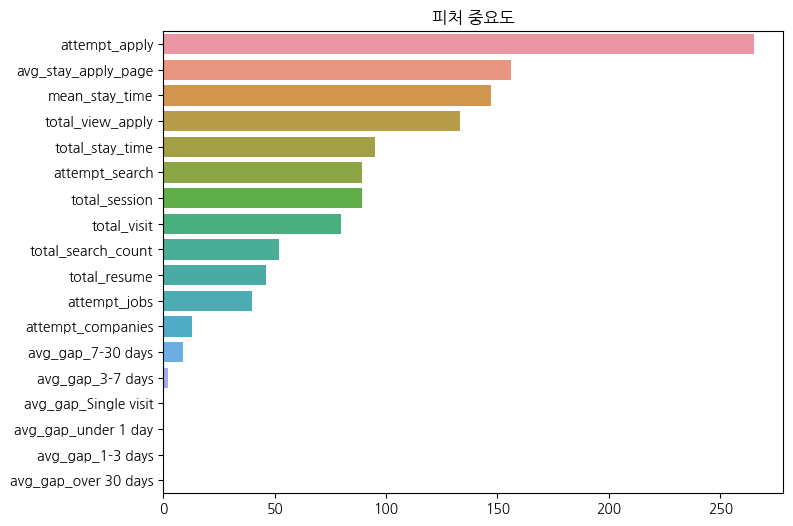

In [ ]:
# 피처 중요도 시각화
ftr_importances_values = lgbm_hyper.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.title('피처 중요도')

sns.barplot(x=ftr_importances, y=ftr_importances.index)

plt.show()

## 지원 확률별 집단 행동 특징 파악
- 모든 모델의 성능이 좋았음
- 다양한 피처로 설명하는 LGBM 모델을 최종 모델로 선정

In [ ]:
result_proba = pd.DataFrame(lgbm_hyper.predict_proba(X_preprocessing)[:, 1], columns=['probability'])

In [ ]:
# 높은 확률로 20회 이상 지원할 집단
high_proba_user = data[result_proba['probability'] >= 0.8]

In [ ]:
# 지원할 집단 비율
len(high_proba_user) / len(data)

0.033792702888220075

In [ ]:
# 높은 확률로 20회 이상 지원하지 않을 집단
low_proba_user = data[result_proba['probability'] <= 0.2]

In [ ]:
# 지원하지 않을 집단 비율
len(low_proba_user) / len(data)

0.9466708907545277

In [ ]:
# 중요 피처 상위 5개
ftr_importances.head()

attempt_apply          265
avg_stay_apply_page    156
mean_stay_time         147
total_view_apply       133
total_stay_time         95
dtype: int32

### attempt_apply(지원 시도)
- 하이퍼 지원군은 평균 187회(중앙값 132회)까지 지원하는 반면, 타겟 지원군은 평균 8회(중앙값 2회)에 불과해 큰 격차가 있으며,
- 이를 해소하기 위해 초기 목표를 평균 20~30회 지원으로 설정하고 초기 지원 유도 및 재참여 캠페인을 강화할 필요가 있음

In [ ]:
high_proba_user['attempt_apply'].describe()

count     640.000000
mean      183.103125
std       202.084115
min        48.000000
25%        98.750000
50%       128.000000
75%       193.250000
max      2036.000000
Name: attempt_apply, dtype: float64

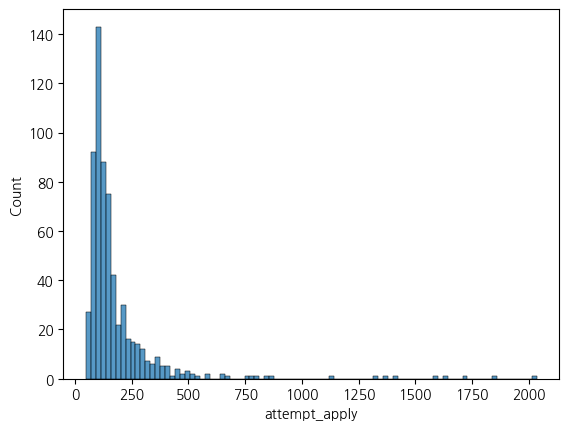

In [ ]:
fig, ax = plt.subplots()

sns.histplot(x = high_proba_user['attempt_apply'])

plt.show()

In [ ]:
low_proba_user['attempt_apply'].describe()

count    17929.000000
mean         8.887556
std         13.392121
min          0.000000
25%          0.000000
50%          2.000000
75%         13.000000
max         90.000000
Name: attempt_apply, dtype: float64

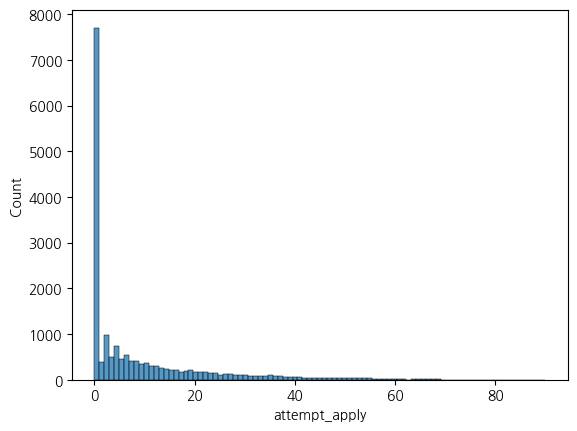

In [ ]:
fig, ax = plt.subplots()

sns.histplot(x = low_proba_user['attempt_apply'])

plt.show()

### mean_stay_time(평균 체류 시간)
- 하이퍼 지원군은 평균 33분 정도 머무는데 비해 타겟 지원군은 평균 22분 정도만 체류
- 흥미를 끌만한 요소들을 가져와서 더 탐색하고 머물도록 유도해야함

In [ ]:
high_proba_user['mean_stay_time'].describe()

count    640.000000
mean      33.904125
std       12.239677
min       11.290000
25%       25.795000
50%       31.800000
75%       38.972500
max      116.820000
Name: mean_stay_time, dtype: float64

In [ ]:
bins = list(range(0, 61, 10)) + [np.inf]  

labels = [f"{i}–{i+10}분" for i in range(0, 60, 10)] + ["장기 체류"]

high_proba_mean_stay_time = pd.cut(high_proba_user['mean_stay_time'], bins=bins, labels=labels, right=False)

In [ ]:
high_proba_mean_stay_time

11       30–40분
15       20–30분
83       30–40분
104      20–30분
161      30–40분
          ...  
18708    10–20분
18722     장기 체류
18739    30–40분
18820    20–30분
18885    30–40분
Name: mean_stay_time, Length: 640, dtype: category
Categories (7, object): ['0–10분' < '10–20분' < '20–30분' < '30–40분' < '40–50분' < '50–60분' < '장기 체류']

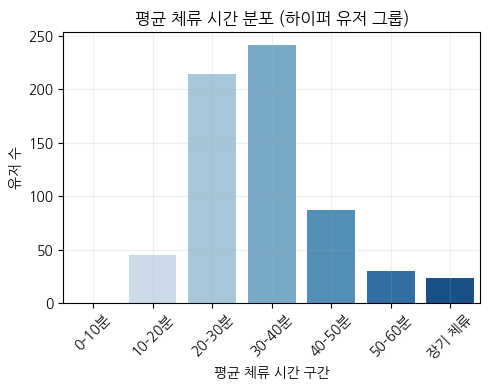

In [ ]:
high_counts = high_proba_mean_stay_time.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(x=high_counts.index, y=high_counts.values, palette='Blues')

plt.xticks(rotation=45)
plt.xlabel('평균 체류 시간 구간')
plt.ylabel('유저 수')
plt.title('평균 체류 시간 분포 (하이퍼 유저 그룹)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# 분포 비율
for idx, ratio in zip(high_counts.index, high_counts / len(high_proba_user)):
    print(f'{idx}: {np.round(ratio,2)}')

0–10분: 0.0
10–20분: 0.07
20–30분: 0.33
30–40분: 0.38
40–50분: 0.14
50–60분: 0.05
장기 체류: 0.04


In [ ]:
low_proba_user['mean_stay_time'].describe()

count    17929.000000
mean        22.666898
std         16.643430
min          2.000000
25%         10.950000
50%         20.250000
75%         30.170000
max        234.550000
Name: mean_stay_time, dtype: float64

In [ ]:
bins = list(range(0, 61, 10)) + [np.inf]  

labels = [f"{i}–{i+10}분" for i in range(0, 60, 10)] + ["장기 체류"]

low_proba_mean_stay_time = pd.cut(low_proba_user['mean_stay_time'], bins=bins, labels=labels, right=False)

In [ ]:
low_proba_mean_stay_time

0        20–30분
1        50–60분
2        30–40분
3         0–10분
4        10–20분
          ...  
18933    40–50분
18934    10–20분
18935    40–50분
18936    10–20분
18937    20–30분
Name: mean_stay_time, Length: 17929, dtype: category
Categories (7, object): ['0–10분' < '10–20분' < '20–30분' < '30–40분' < '40–50분' < '50–60분' < '장기 체류']

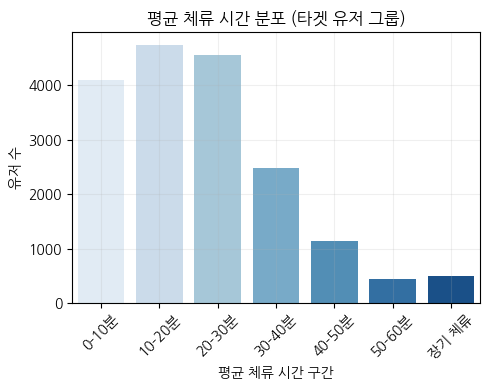

In [ ]:
low_counts = low_proba_mean_stay_time.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(x=low_counts.index, y=low_counts.values, palette='Blues')

plt.xticks(rotation=45)
plt.xlabel('평균 체류 시간 구간')
plt.ylabel('유저 수')
plt.title('평균 체류 시간 분포 (타겟 유저 그룹)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# 분포 비율
for idx, ratio in zip(low_counts.index, low_counts / len(low_proba_user)):
    print(f'{idx}: {np.round(ratio, 2)}')

0–10분: 0.23
10–20분: 0.26
20–30분: 0.25
30–40분: 0.14
40–50분: 0.06
50–60분: 0.02
장기 체류: 0.03


### avg_stay_apply_page (채용공고 평균 체류 시간)
- 타겟 지원군은 70% 이상이 1분 미만으로 채용공고 페이지를 빠르게 훑는 경우가 많은 반면,
- 하이퍼 지원군은 2~4분 구간에 걸쳐 고르게 분포하며 대부분의 공고를 꼼꼼히 읽는 경향을 보임

In [ ]:
high_proba_user['avg_stay_apply_page'].describe()

count    640.000000
mean       3.057156
std        1.672897
min        0.130000
25%        1.800000
50%        2.900000
75%        4.012500
max       10.430000
Name: avg_stay_apply_page, dtype: float64

In [ ]:
bins = list(range(0, 11)) + [np.inf]  

labels = [f"{i}–{i+1}분" for i in range(0, 10)] + ["장기 체류"]

high_proba_mean_page_stay_time = pd.cut(high_proba_user['avg_stay_apply_page'], bins=bins, labels=labels, right=False)

In [ ]:
high_proba_mean_page_stay_time

11       6–7분
15       4–5분
83       3–4분
104      4–5분
161      3–4분
         ... 
18708    1–2분
18722    3–4분
18739    3–4분
18820    4–5분
18885    2–3분
Name: avg_stay_apply_page, Length: 640, dtype: category
Categories (11, object): ['0–1분' < '1–2분' < '2–3분' < '3–4분' ... '7–8분' < '8–9분' < '9–10분' < '장기 체류']

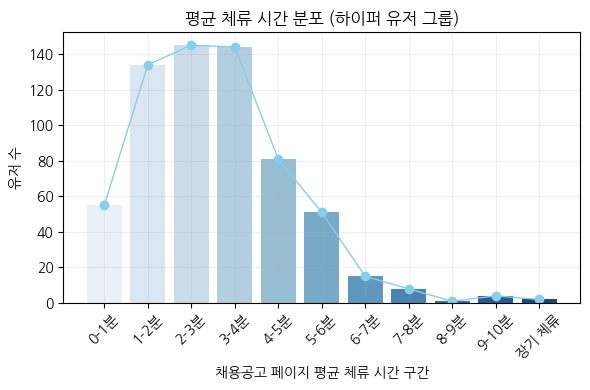

In [ ]:
high_counts = high_proba_mean_page_stay_time.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x=high_counts.index, y=high_counts.values, palette='Blues')
ax.plot(high_counts.index, high_counts.values, color='skyblue', marker='o', linestyle='-', linewidth=1)

plt.xticks(rotation=45)
plt.xlabel('채용공고 페이지 평균 체류 시간 구간')
plt.ylabel('유저 수')
plt.title('평균 체류 시간 분포 (하이퍼 유저 그룹)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
low_proba_user['avg_stay_apply_page'].describe()

count    17929.000000
mean         2.246423
std          3.488109
min          0.000000
25%          0.280000
50%          1.180000
75%          2.960000
max         62.200000
Name: avg_stay_apply_page, dtype: float64

In [ ]:
bins = list(range(0, 11)) + [np.inf]

labels = [f"{i}–{i+1}분" for i in range(0, 10)] + ["장기 체류"]

low_proba_mean_page_stay_time = pd.cut(low_proba_user['avg_stay_apply_page'], bins=bins, labels=labels, right=False)

In [ ]:
low_proba_mean_page_stay_time

0         0–1분
1         1–2분
2         4–5분
3         0–1분
4         1–2분
         ...  
18933    장기 체류
18934     0–1분
18935    9–10분
18936     4–5분
18937     2–3분
Name: avg_stay_apply_page, Length: 17929, dtype: category
Categories (11, object): ['0–1분' < '1–2분' < '2–3분' < '3–4분' ... '7–8분' < '8–9분' < '9–10분' < '장기 체류']

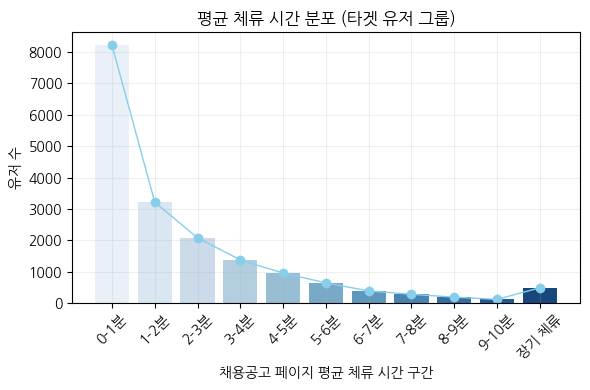

In [ ]:
low_counts = low_proba_mean_page_stay_time.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x=low_counts.index, y=low_counts.values, palette='Blues', ax=ax)
ax.plot(low_counts.index, low_counts.values, color='skyblue', marker='o', linestyle='-', linewidth=1)

plt.xticks(rotation=45)
plt.xlabel('채용공고 페이지 평균 체류 시간 구간')
plt.ylabel('유저 수')
plt.title('평균 체류 시간 분포 (타겟 유저 그룹)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### attempt_search (통합 검색 횟수)
- 하이퍼 지원군은 평균 20회 정도 검색해본 반면, 타겟 지원군은 평균 5회 정도 검색
- 타겟 지원군이 흥미를 가질 수 있는 검색 결과를 얻을 수 있도록 다양한 채용 공고 필요

In [ ]:
high_proba_user['attempt_search'].describe()

count    640.000000
mean      20.370313
std       34.405691
min        0.000000
25%        3.000000
50%        9.000000
75%       22.250000
max      354.000000
Name: attempt_search, dtype: float64

In [ ]:
low_proba_user['attempt_search'].describe()

count    17929.000000
mean         4.709744
std         13.756183
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max        546.000000
Name: attempt_search, dtype: float64

### total_stay_time (총 체류 시간)
- 하이퍼 지원 그룹 평균: 116시간
- 타겟 지원 그룹 평균: 17시간
- 총 체류 시간을 어느 정도로 끌어올려야할지의 문제

In [ ]:
high_proba_user['total_stay_time'].describe()

count      640.000000
mean      2699.417188
std       2910.277024
min        158.580000
25%        930.347500
50%       1844.120000
75%       3403.807500
max      29863.970000
Name: total_stay_time, dtype: float64

In [ ]:
low_proba_user['total_stay_time'].describe()

count    17929.000000
mean       429.762775
std       1146.305018
min          2.000000
25%         31.800000
50%        141.400000
75%        442.820000
max      40698.430000
Name: total_stay_time, dtype: float64

# 9. 결과 해석 및 인사이트 도출
1. 콘텐츠 큐레이션 강화
    - 주 사용자층인 경력 SW 개발자들이 선호하는 키워드(언어, 라이브러리, 원격·하이브리드, 연봉공개 등)를 기반으로 채용공고를 자동 필터링 및 추천
    - “맞춤형 공고” 위젯이나 푸시 알림으로 이들이 실제로 원하는 포지션만 선별 제공

2. 기업 제휴 전략 수립
    - “우리 플랫폼에는 경력직 SW 개발자 풀(pool)이 풍부합니다”라는 데이터를 활용해, 상위 20% 경험자 타깃 기업과 우선 제휴
    - 경력직 공고를 의무적으로 연봉·근무 형태 공개 토록 하거나, 공개 시 노출 우대 인센티브 제공

3. 리마인드·재참여 캠페인
    - 이직 준비 주기(약 6개월)를 고려한 자동 알림
        - “지난 지원 이후 6개월이 지났어요. 다시 탐색해 보시겠어요?”
    - 이탈 사용자 대상 프로모션·쿠폰 제공
        - 채용공고 북마크 활성화 후 비활성화 시점에 맞춘 재유입 메시지

4. 선순환 피드백 루프 구축
    - 사용자 행동 지표(AARRR, 피처 중요도)를 정기 리포트화
    - 성과가 좋은 기업·공고와 사용자 행동을 실시간 연동해 “우리 플랫폼에서 ●●님과 같은 지원자가 합격했습니다” 등의 프로모션

5. 통합 검색 개선(컨텍스트 기반 추천)
    - ‘다른 사람들은 이런 공고도 검색했어요’ 위젯
    - ‘이력서에 맞는 공고’ 맞춤형 카드

# 10. 회고
1. 지표 한계
    - 로그 데이터만으로는 ‘Revenue’·‘Referral’ 단계 측정 불가
    - 전환(지원) 이전의 행동만 분석 가능했음

2. 분석 기간 편차
    - 2023년 말일수록 데이터 수집 기간이 짧아 행동 패턴 변화 해석에 제약

3. 이상치 처리
    - 별도 이상치 제거 없이 모델 학습 진행 랜덤포레스트·LGBM 특성상 일부 이상치에 관대한 점을 감안하였으나
    - '실제 사용자 패턴' vs '오류 로그 구분'에는 한계
    - ‘지원자’ 외에 기업 채용 담당자도 주요 사용자로 추정 → 채용 리서치 목적으로 장시간 페이지 체류 가능 → 체류 시간만으로 지원 의도 단정 어려움

4. 인사이트 검증 미비
    - 제안된 A/B 테스트·UI 개선 방안은 가설 수준으로 실제 검증 전
    - 실험 설계 및 결과 반영 단계 필요

5. UI·UX 데이터 부재
    - 화면 구성·클릭 경로 등 정성적 사용자 경험 정보 부족
    - 보다 구체적 개선안을 위해서는 화면 단위 로그·유저 정보 필요

6. 프로젝트 초점: 전반적 플랫폼 특성 파악
    - 세부 디테일보다는 큰 틀에서의 행동 흐름·퍼널·코호트 구조를 이해하는 데 주력
    - 플랫폼 전반의 병목 지점과 주요 지표 동향을 빠르게 진단